---
# SECTION 1 — DATA LAYER
> Source: `notebooks/04_full_pipeline.ipynb` | Branch: Branch B
---


# 04 - Full NER Data Pipeline

Single notebook that executes every data engineering step in the correct order:

```
1. Load raw dataset
2. Clean text
3. Split  (train 70 / val 15 / test 15)  — stratified by job category
4. BIO annotate all three splits via Gemini API
5. Tokenizer alignment for the selected model family
6. Export HuggingFace DatasetDict
```

**Why this order?** Cleaning and splitting happen before annotation so the LLM always sees clean text, and the splits are fixed before any labelling occurs.

**Output:** `data/processed/resume_ner_hf/` for BERT, or a model-specific folder such as `data/processed/resume_ner_hf_roberta-base/` for RoBERTa — a HuggingFace `DatasetDict` ready for model engineers.

## 1) Install dependencies

In [1]:
# Uncomment in Colab / fresh environment
# !pip -q install google-genai datasets transformers scikit-learn pandas seaborn matplotlib

## 2) Imports

In [1]:
import json
import os
import re
import time
import sys
from collections import Counter
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import Dataset, DatasetDict, Features, Sequence, Value, load_dataset
from google import genai
from google.genai import errors as genai_errors
from google.genai import types
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

/Users/alyani/Desktop/grad school/WQF7007/project/wqf7007-automated-cv-parser/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3) Configuration

In [ ]:
# -- Gemini / Vertex AI -------------------------------------------------------
GEMINI_MODEL = "gemini-3.5-flash"
VERTEX_PROJECT_ID = "project-89fb5bc1-75d8-4158-896"
VERTEX_LOCATION = "global"
CALL_DELAY = 0.1
MAX_CONCURRENT_REQUESTS = 5
MAX_RETRIES = 8
MAX_OUTPUT_TOKENS = 4096
CHUNK_CHARS = 6000
CHUNK_OVERLAP = 250

# -- Dataset -----------------------------------------------------------------
DATASET_NAME = "yashpwr/resume-ner-training-data"
CATEGORY_QUESTION = "What job category does this resume best fit?"
MAX_SAMPLES = None   # None = use all available rows

# -- Split -------------------------------------------------------------------
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42
MIN_CLASS_SAMPLES = 3   # classes below this are merged into OTHER before splitting

# -- NER labels ---------------------------------------------------------------
LABEL_LIST = ["O", "B-JOB_TITLE", "I-JOB_TITLE", "B-SKILL", "I-SKILL", "B-EDUCATION", "I-EDUCATION"]
LABEL2ID = {l: i for i, l in enumerate(LABEL_LIST)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}
IGNORE_IDX = -100

# -- Tokenizer/model family ---------------------------------------------------
# Use "bert-base-uncased" for the existing BERT dataset, or "roberta-base" for RoBERTa.
MODEL_CHECKPOINT = "roberta-base"
MAX_LENGTH = 512
STRIDE = 128   # overlap between consecutive sliding-window chunks

# -- Output ------------------------------------------------------------------
TOKENIZER_FAMILY = "roberta" if "roberta" in MODEL_CHECKPOINT.lower() else "bert"
MODEL_OUTPUT_SUFFIX = "" if MODEL_CHECKPOINT == "bert-base-uncased" else f"_{MODEL_CHECKPOINT.replace('/', '-')}"
OUT_HF = Path(f"../data/processed/resume_ner_hf{MODEL_OUTPUT_SUFFIX}")
OUT_CSV = Path("../data/processed/resume_bio_annotated_full.csv")
OUT_CHECKPOINT_DIR = OUT_CSV.parent / "annotation_checkpoints"
CHECKPOINT_EVERY = 25
OUT_HF.parent.mkdir(parents=True, exist_ok=True)
OUT_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Config loaded.")
print(f"Label map: {LABEL2ID}")
print(f"Vertex project: {VERTEX_PROJECT_ID}")
print(f"Vertex location: {VERTEX_LOCATION}")
print(f"Model: {GEMINI_MODEL}")
print(f"Chunking: {CHUNK_CHARS:,} chars, {CHUNK_OVERLAP:,} overlap")
if CALL_DELAY:
    print(f"Configured delay: {CALL_DELAY:.1f}s between completed calls")
else:
    print("Configured delay: none")
print(f"Vertex workers: {MAX_CONCURRENT_REQUESTS}")
print(f"Tokenizer family: {TOKENIZER_FAMILY}")
print(f"Sliding window : max_length={MAX_LENGTH}, stride={STRIDE}")
print(f"HF output path : {OUT_HF}")

## 4) Gemini client setup

Uses Vertex AI through the Google GenAI SDK and the configured Google Cloud project.

In [ ]:
print("Initializing Vertex AI Gemini client...")
gemini_client = genai.Client(
    vertexai=True,
    project=VERTEX_PROJECT_ID,
    location=VERTEX_LOCATION,
)
print(f"Vertex AI client ready - model: {GEMINI_MODEL}")

---
## STEP 1 — Load raw dataset

In [4]:
print("Loading dataset from HuggingFace ...")
raw_dataset = load_dataset(DATASET_NAME)

cat_re = re.compile(r"best fits the\s+([A-Z\-]+)\s+category", re.IGNORECASE)

def get_msg(example, role):
    for m in example["messages"]:
        if m["role"] == role:
            return m["content"]
    return ""

records = []
for ex in raw_dataset["train"]:
    user  = get_msg(ex, "user")
    lines = user.strip().splitlines()
    if not lines or lines[0] != CATEGORY_QUESTION:
        continue
    m = cat_re.search(get_msg(ex, "assistant"))
    if not m:
        continue
    # Case-insensitive split on "resume:"
    parts  = re.split(r"resume:", user, maxsplit=1, flags=re.IGNORECASE)
    resume = parts[1].strip() if len(parts) > 1 else user.strip()
    records.append({"resume_text": resume, "job_category": m.group(1).upper()})

df_raw = pd.DataFrame(records)
if MAX_SAMPLES:
    df_raw = df_raw.head(MAX_SAMPLES)

print(f"Extracted rows : {len(df_raw):,}")
print(f"Unique categories: {df_raw['job_category'].nunique()}")
df_raw.head(3)

Loading dataset from HuggingFace ...


Extracted rows : 2,483
Unique categories: 24


,resume_text,job_category
0,What job category does this resume best fit?\n...,TEACHER
1,What job category does this resume best fit?\n...,HR
2,What job category does this resume best fit?\n...,ADVOCATE


---
## STEP 2 — Clean text

In [5]:
def clean_resume(text: str) -> str:
    # Drop non-UTF-8 characters
    text = text.encode("utf-8", errors="ignore").decode("utf-8")
    # Collapse 3+ newlines to 2
    text = re.sub(r"\n{3,}", "\n\n", text)
    # Collapse multiple spaces / tabs to single space
    text = re.sub(r"[ \t]+", " ", text)
    # Strip leading/trailing whitespace per line
    text = "\n".join(line.strip() for line in text.splitlines())
    return text.strip()


def strip_category_prefix(text: str, category: str) -> str:
    if not text.startswith(CATEGORY_QUESTION):
        return text
    text = text[len(CATEGORY_QUESTION):].strip()
    if text.upper().startswith(category.upper()):
        text = text[len(category):].strip()
    return text


df_raw["resume_text"] = df_raw["resume_text"].apply(clean_resume)
df_raw["resume_text"] = df_raw.apply(
    lambda row: strip_category_prefix(row["resume_text"], row["job_category"]), axis=1
)

# Sanity check - no empty resumes after cleaning
empty = (df_raw["resume_text"].str.strip() == "").sum()
assert empty == 0, f"{empty} empty resumes after cleaning"

prefix_count = df_raw["resume_text"].str.startswith(CATEGORY_QUESTION).sum()
assert prefix_count == 0, f"{prefix_count} resumes still contain the classifier question prefix"

print(f"Cleaning done. Avg length: {df_raw['resume_text'].str.len().mean():.0f} chars")

Cleaning done. Avg length: 5978 chars


---
## STEP 3 — Split (stratified 70 / 15 / 15)

Classes with fewer than `MIN_CLASS_SAMPLES` rows cannot be stratified across three splits.  
These are temporarily merged into `OTHER` for splitting, then the original label is restored.

Class distribution:
job_category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      119
ADVOCATE                  118
ACCOUNTANT                118
CHEF                      118
ENGINEERING               118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
BANKING                   115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22


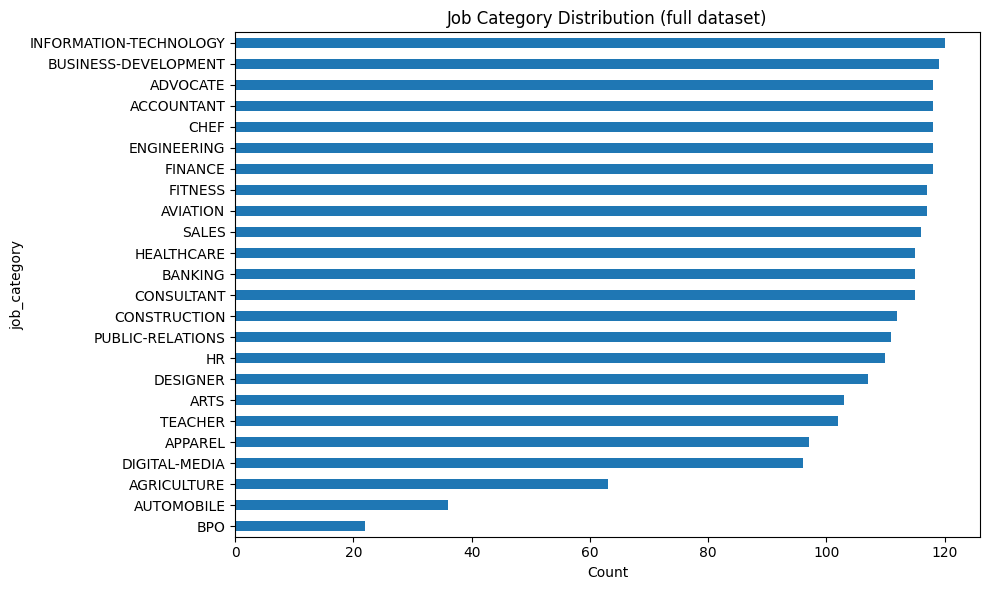


All classes have enough samples for stratification.


In [6]:
# ── Class distribution ────────────────────────────────────────────────────────
counts = df_raw["job_category"].value_counts()
print("Class distribution:")
print(counts.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
counts.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Job Category Distribution (full dataset)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.close(fig)

small_classes = counts[counts < MIN_CLASS_SAMPLES].index.tolist()
if small_classes:
    print(f"\nClasses merged into OTHER for splitting (< {MIN_CLASS_SAMPLES} samples): {small_classes}")
else:
    print("\nAll classes have enough samples for stratification.")

In [7]:
# ── Temporary stratification label ───────────────────────────────────────────
df_raw["_strat_label"] = df_raw["job_category"].apply(
    lambda c: "OTHER" if c in small_classes else c
)

# ── First split: (train+val) vs test ─────────────────────────────────────────
df_trainval, df_test = train_test_split(
    df_raw,
    test_size=TEST_RATIO,
    stratify=df_raw["_strat_label"],
    random_state=RANDOM_SEED,
)

# ── Second split: train vs val ────────────────────────────────────────────────
val_size_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_size_adjusted,
    stratify=df_trainval["_strat_label"],
    random_state=RANDOM_SEED,
)

# ── Clean up temp column ──────────────────────────────────────────────────────
for df in (df_train, df_val, df_test):
    df.drop(columns=["_strat_label"], inplace=True)
    df.reset_index(drop=True, inplace=True)

assert len(df_train) + len(df_val) + len(df_test) == len(df_raw)

print(f"Train : {len(df_train):>5,} rows  ({len(df_train)/len(df_raw):.0%})")
print(f"Val   : {len(df_val):>5,} rows  ({len(df_val)/len(df_raw):.0%})")
print(f"Test  : {len(df_test):>5,} rows  ({len(df_test)/len(df_raw):.0%})")

Train : 1,737 rows  (70%)
Val   :   373 rows  (15%)
Test  :   373 rows  (15%)


---
# SECTION 2 — ANNOTATION LAYER (probabilistic)
> Source: `notebooks/04_full_pipeline.ipynb` | Branch: Branch B
---


---
## STEP 4 — BIO annotation via Gemini API

All three splits are annotated separately and sequentially.  
The LLM is a frozen extractor — it is not trained on this data — so annotating val and test does not constitute data leakage.

In [8]:
# -- Gemini call --------------------------------------------------------------
SYSTEM_PROMPT = (
    "You are an expert CV parser creating token-level NER training labels. "
    "Extract only high-confidence entities that appear exactly in the supplied resume chunk. "
    "Always respond with valid JSON only, no explanation and no markdown fences."
)

USER_TEMPLATE = """Extract named entities from this resume chunk.

Return ONLY this JSON structure:
{{
  "entities": [
    {{"label": "JOB_TITLE", "text": "..."}},
    {{"label": "SKILL", "text": "..."}},
    {{"label": "EDUCATION", "text": "..."}}
  ]
}}

Rules:
- text MUST be copied exactly from this chunk.
- Use only these labels: JOB_TITLE, SKILL, EDUCATION.
- JOB_TITLE: job roles/positions only, not industries or departments.
- SKILL: concrete tools, technologies, methods, certifications, or well-formed professional abilities.
- Do not label generic nouns as SKILL, such as clients, quality, business, financial, retail, policies, meetings, office, or focus.
- EDUCATION: degrees, institutions, majors/minors, formal certificates, or fields of study in education/training/certification context.
- Do not label every mention of a subject word as EDUCATION; only label it when it is part of an education credential/context.
- Copy spans EXACTLY as they appear in the text.
- Assign each exact span to only one label. If ambiguous, prefer EDUCATION only in education/training/certification context.

Resume chunk:
{chunk_text}"""

ALLOWED_ENTITY_LABELS = {"JOB_TITLE", "SKILL", "EDUCATION"}
ENTITY_LABEL_PRIORITY = {"EDUCATION": 0, "JOB_TITLE": 1, "SKILL": 2}
GENERIC_SINGLE_TOKEN_SKILLS = {
    "accounting", "benefits", "billing", "budget", "business", "client", "clients",
    "contracts", "credit", "documentation", "financial", "focus", "inventory",
    "managing", "marketing", "materials", "meetings", "office", "personnel",
    "policies", "processes", "quality", "research", "retail",
}
KNOWN_SINGLE_TOKEN_SKILLS = {
    "access", "ajax", "aws", "azure", "c", "c#", "c++", "css", "excel", "git",
    "github", "html", "java", "javascript", "jira", "jquery", "linux", "mysql",
    "oracle", "outlook", "powerpoint", "python", "quickbooks", "react", "sap",
    "sql", "tableau", "unix", "vb", "word",
}
SECTION_HEADER_RE = re.compile(
    r"(?im)^\s*(summary|profile|skills?|technical skills|core competencies|"
    r"professional experience|work experience|employment|education|certifications?|"
    r"licenses?|training|projects?|highlights?|accomplishments?)\s*:?\s*$"
)
EDUCATION_CONTEXT_RE = re.compile(
    r"\b(education|degree|university|college|school|institute|academy|"
    r"certification|certificate|certified|training|coursework|major|minor|"
    r"graduate|graduated|postgraduate|"
    r"bachelor|bachelors|master|masters|mba|phd|associate|diploma|gpa)\b",
    re.IGNORECASE,
)
DEGREE_OR_CERT_RE = re.compile(
    r"\b(b\.?s\.?|b\.?a\.?|m\.?s\.?|m\.?a\.?|mba|phd|bachelor|bachelors|"
    r"master|masters|graduate|postgraduate|associate|degree|diploma|certificate|certification|"
    r"certified|license|licensed|gpa)\b",
    re.IGNORECASE,
)


def split_text_chunks(text: str, max_chars: int = CHUNK_CHARS, overlap_chars: int = CHUNK_OVERLAP) -> list[dict]:
    overlap_chars = max(0, min(overlap_chars, max_chars // 3))
    chunks = []
    start = 0
    while start < len(text):
        hard_end = min(len(text), start + max_chars)
        end = hard_end
        if hard_end < len(text):
            boundary_candidates = [
                m.start() for m in SECTION_HEADER_RE.finditer(text, start + max_chars // 3, hard_end)
            ]
            if boundary_candidates:
                end = boundary_candidates[-1]
            else:
                sentence_break = text.rfind(". ", start + max_chars // 2, hard_end)
                newline_break = text.rfind("\n", start + max_chars // 2, hard_end)
                space_break = text.rfind(" ", start + max_chars // 2, hard_end)
                end = max(sentence_break + 1, newline_break, space_break)
                if end <= start:
                    end = hard_end
        raw_chunk = text[start:end]
        chunk_text = raw_chunk.strip()
        leading_ws = len(raw_chunk) - len(raw_chunk.lstrip())
        if chunk_text:
            chunks.append({"start": start + leading_ws, "text": chunk_text})
        if end >= len(text):
            break
        start = max(end - overlap_chars, start + 1)
    return chunks


def extract_response_json(text_content: str) -> list[dict]:
    try:
        parsed = json.loads(text_content)
    except json.JSONDecodeError:
        start = text_content.find("{")
        end = text_content.rfind("}")
        if start == -1 or end == -1 or end <= start:
            raise
        parsed = json.loads(text_content[start:end + 1])

    if isinstance(parsed, list):
        values = parsed
    elif isinstance(parsed, dict):
        values = parsed.get("entities", [])
    else:
        return []
    if not isinstance(values, list):
        return []

    entities = []
    for value in values:
        if not isinstance(value, dict):
            continue
        label = str(value.get("label", "")).strip().upper().replace("-", "_")
        text = str(value.get("text", "")).strip()
        if label in ALLOWED_ENTITY_LABELS and text:
            entities.append({"label": label, "text": text})
    return entities


def call_gemini_chunk(chunk_text: str, chunk_start: int) -> list[dict] | None:
    for attempt in range(MAX_RETRIES):
        try:
            resp = gemini_client.models.generate_content(
                model=GEMINI_MODEL,
                contents=USER_TEMPLATE.format(chunk_text=chunk_text),
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM_PROMPT,
                    response_mime_type="application/json",
                    temperature=0.0,
                    max_output_tokens=MAX_OUTPUT_TOKENS,
                    thinking_config=types.ThinkingConfig(
                        thinking_level=types.ThinkingLevel.MINIMAL
                    ),
                ),
            )
            text_content = "".join(
                part.text
                for part in resp.candidates[0].content.parts
                if hasattr(part, "text") and part.text
            )
            return extract_response_json(text_content)
        except json.JSONDecodeError:
            print(f"  invalid JSON on attempt {attempt + 1}/{MAX_RETRIES}", flush=True)
            time.sleep(2 ** attempt)
        except genai_errors.ClientError as e:
            status_code = getattr(e, "status_code", None)
            if status_code is None and ("429" in str(e) or "RESOURCE_EXHAUSTED" in str(e)):
                status_code = 429
            if status_code == 429:
                wait = 2 ** (attempt + 1)
                print(f"  rate limited - waiting {wait}s", flush=True)
                time.sleep(wait)
            else:
                print(f"  API error {status_code}: {e}", flush=True)
                return None
        except Exception as e:
            print(f"  error: {e}", flush=True)
            time.sleep(2 ** attempt)
    return None


# -- BIO conversion -----------------------------------------------------------
def token_offsets(text: str) -> list[tuple[str, int, int]]:
    return [(m.group(0), m.start(), m.end()) for m in re.finditer(r"\S+", text)]


def clean_match_token(token: str) -> str:
    return token.lower().strip(".,;:()\"'[]{}<>-*")


def is_generic_skill(span_text: str) -> bool:
    cleaned = clean_match_token(span_text)
    if " " in span_text.strip():
        return False
    if cleaned in KNOWN_SINGLE_TOKEN_SKILLS:
        return False
    if cleaned in GENERIC_SINGLE_TOKEN_SKILLS:
        return True
    if len(cleaned) <= 2 and not span_text.strip().isupper():
        return True
    return False


def has_education_context(text: str, start: int, end: int, span_text: str) -> bool:
    if DEGREE_OR_CERT_RE.search(span_text):
        return True
    window = text[max(0, start - 220):min(len(text), end + 160)]
    return bool(EDUCATION_CONTEXT_RE.search(window))


def find_span_in_chunk(chunk_text: str, span_text: str) -> tuple[int, int] | None:
    span_text = span_text.strip()
    if not span_text:
        return None

    start = chunk_text.find(span_text)
    if start >= 0:
        return start, start + len(span_text)

    if span_text.split():
        pattern = r"\s+".join(re.escape(part) for part in span_text.split())
        for flags in (0, re.IGNORECASE):
            match = re.search(pattern, chunk_text, flags=flags)
            if match:
                return match.start(), match.end()

    span_tokens = [clean_match_token(token) for token in span_text.split()]
    span_tokens = [token for token in span_tokens if token]
    if not span_tokens:
        return None

    chunk_offsets = token_offsets(chunk_text)
    chunk_norm = [clean_match_token(token) for token, _, _ in chunk_offsets]
    width = len(span_tokens)
    for idx in range(len(chunk_norm) - width + 1):
        if chunk_norm[idx:idx + width] == span_tokens:
            return chunk_offsets[idx][1], chunk_offsets[idx + width - 1][2]
    return None


def resolve_chunk_entity(full_text: str, chunk_start: int, chunk_text: str, entity: dict) -> tuple[dict | None, str | None]:
    label = entity["label"]
    text_value = entity["text"]
    span = find_span_in_chunk(chunk_text, text_value)
    if span is None:
        return None, "span_not_found_in_chunk"

    start, end = span
    global_start = chunk_start + start
    global_end = chunk_start + end
    span_text = full_text[global_start:global_end]

    if label == "SKILL" and is_generic_skill(span_text):
        return None, "generic_single_token_skill"
    if label == "EDUCATION" and not has_education_context(full_text, global_start, global_end, span_text):
        return None, "education_without_context"

    return {"label": label, "text": span_text, "source_text": text_value, "start": global_start, "end": global_end}, None

def spans_to_bio(text: str, entities: list[dict]) -> tuple[list[str], list[str], int]:
    offsets = token_offsets(text)
    tokens = [token for token, _, _ in offsets]
    tags = ["O"] * len(tokens)
    candidates = []
    misses = 0
    seen = set()

    for entity in entities:
        key = (entity["start"], entity["end"], entity["label"])
        if key in seen:
            continue
        seen.add(key)
        token_indexes = [
            idx for idx, (_, tok_start, tok_end) in enumerate(offsets)
            if tok_start >= entity["start"] and tok_end <= entity["end"]
        ]
        if (
            not token_indexes
            or offsets[token_indexes[0]][1] != entity["start"]
            or offsets[token_indexes[-1]][2] != entity["end"]
        ):
            misses += 1
            continue
        candidates.append({
            "token_start": token_indexes[0],
            "token_end": token_indexes[-1] + 1,
            "label": entity["label"],
        })

    candidates.sort(
        key=lambda c: (
            ENTITY_LABEL_PRIORITY[c["label"]],
            -(c["token_end"] - c["token_start"]),
            c["token_start"],
        )
    )

    occupied = [False] * len(tokens)
    for candidate in candidates:
        start = candidate["token_start"]
        end = candidate["token_end"]
        label = candidate["label"]
        if any(occupied[start:end]):
            misses += 1
            continue
        tags[start] = f"B-{label}"
        for idx in range(start + 1, end):
            tags[idx] = f"I-{label}"
        for idx in range(start, end):
            occupied[idx] = True
    return tokens, tags, misses


def annotate_text(text: str) -> tuple[list[str], list[str], dict, int] | None:
    accepted = []
    rejected = []
    raw_count = 0
    chunks = split_text_chunks(text)

    for chunk in chunks:
        raw_entities = call_gemini_chunk(chunk["text"], chunk["start"])
        if raw_entities is None:
            return None
        raw_count += len(raw_entities)
        for entity in raw_entities:
            validated, reason = resolve_chunk_entity(text, chunk["start"], chunk["text"], entity)
            if validated is None:
                rejected.append({"reason": reason, **entity, "chunk_start": chunk["start"]})
            else:
                accepted.append(validated)

    deduped = []
    seen = set()
    for entity in accepted:
        key = (entity["start"], entity["end"], entity["label"])
        if key in seen:
            continue
        seen.add(key)
        deduped.append(entity)
    accepted = deduped

    tokens, tags, misses = spans_to_bio(text, accepted)
    raw_payload = {"entities": accepted, "rejected": rejected, "chunk_count": len(chunks)}
    return tokens, tags, raw_payload, (raw_count - len(accepted)) + misses


# -- Annotation loop ----------------------------------------------------------
def annotate_split(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    rows = []
    failed = []
    total = len(df)

    print(f"\n{'='*60}")
    print(f"Annotating {split_name.upper()} split ({total} rows) ...")
    print(f"{'='*60}")

    for i, (_, row) in enumerate(df.iterrows()):
        text = row["resume_text"]
        category = row["job_category"]

        annotated = annotate_text(text)
        if annotated is None:
            failed.append(i)
            print(f"[{i+1:>4}/{total}] FAILED - {category}", flush=True)
            time.sleep(CALL_DELAY)
            continue

        tokens, tags, entities, misses = annotated
        non_o = sum(1 for t in tags if t != "O")

        rows.append({
            "split": split_name,
            "job_category": category,
            "resume_text": text,
            "tokens": json.dumps(tokens),
            "bio_tags": json.dumps(tags),
            "entities_raw": json.dumps(entities),
        })

        print(
            f"[{i+1:>4}/{total}] OK  {category:<25} entities={non_o:>3} "
            f"rejected_or_unmapped={misses}",
            flush=True,
        )
        time.sleep(CALL_DELAY)

    print(f"\n{split_name.upper()} done - {len(rows)} annotated / {len(failed)} failed")
    return pd.DataFrame(rows)


print("Offset-based Vertex annotation functions ready.")

Annotation functions ready.


In [9]:
if OUT_CSV.exists():
    print(f"Annotations already exist — loading from {OUT_CSV.resolve()}")
    df_ann_all   = pd.read_csv(OUT_CSV)
    df_ann_train = df_ann_all[df_ann_all["split"] == "train"].reset_index(drop=True)
    df_ann_val   = df_ann_all[df_ann_all["split"].isin(["val", "validation"])].reset_index(drop=True)
    df_ann_test  = df_ann_all[df_ann_all["split"] == "test"].reset_index(drop=True)
    print(f"Loaded: train={len(df_ann_train):,} / val={len(df_ann_val):,} / test={len(df_ann_test):,}")
else:
    df_ann_train = annotate_split(df_train, "train")
    df_ann_val   = annotate_split(df_val,   "val")
    df_ann_test  = annotate_split(df_test,  "test")

    # ── Combine and save raw BIO CSV ────────────────────────────────────────────
    df_ann_all = pd.concat([df_ann_train, df_ann_val, df_ann_test], ignore_index=True)
    df_ann_all.to_csv(OUT_CSV, index=False)
    print(f"Raw BIO annotations saved → {OUT_CSV.resolve()}")
    print(f"Total rows: {len(df_ann_all):,}  (train={len(df_ann_train)} / val={len(df_ann_val)} / test={len(df_ann_test)})")


Annotations already exist — loading from /Users/alyani/Desktop/grad school/WQF7007/project/wqf7007-automated-cv-parser/data/processed/resume_bio_annotated_full.csv
Loaded: train=1,726 / val=371 / test=371


---
# SECTION 3 — VALIDATION LAYER (deterministic gate)
> Source: `notebooks/04_full_pipeline.ipynb` | Branch: Branch B
---


## Data quality checks

In [10]:
# DQ-1: token / BIO list length parity
mismatches = []
for i, row in df_ann_all.iterrows():
    t = json.loads(row["tokens"])
    b = json.loads(row["bio_tags"])
    if len(t) != len(b):
        mismatches.append((i, len(t), len(b)))

if mismatches:
    print(f"FAIL — {len(mismatches)} rows have mismatched lengths:")
    for idx, tl, bl in mismatches[:10]:
        print(f"  row {idx}: tokens={tl}, bio_tags={bl}")
    raise ValueError("Token/BIO length mismatch — fix upstream in annotation step.")
else:
    print("DQ-1 PASS — all token/BIO lists are equal length")

# DQ-2: valid tag vocabulary
all_tags = {t for row in df_ann_all["bio_tags"] for t in json.loads(row)}
unexpected = all_tags - set(LABEL_LIST)
if unexpected:
    print(f"WARN — unexpected tags found: {unexpected}")
else:
    print("DQ-2 PASS — all tags are within the expected vocabulary")

# DQ-3: overall tag distribution
flat_tags = [t for row in df_ann_train["bio_tags"] for t in json.loads(row)]
tag_counts = Counter(flat_tags)
total_tags = sum(tag_counts.values())
print(f"\nTrain tag distribution:")
for tag, cnt in sorted(tag_counts.items()):
    print(f"  {tag:<20} {cnt:>8,}  ({cnt/total_tags:.1%})")
print(f"\nO-tag rate: {tag_counts.get('O',0)/total_tags:.1%}  (healthy: 85–95%)")

DQ-1 PASS — all token/BIO lists are equal length
DQ-2 PASS — all tags are within the expected vocabulary

Train tag distribution:
  B-EDUCATION             1,256  (0.1%)
  B-JOB_TITLE            11,764  (0.8%)
  B-SKILL                50,446  (3.6%)
  I-EDUCATION             4,152  (0.3%)
  I-JOB_TITLE            15,819  (1.1%)
  I-SKILL                35,598  (2.5%)
  O                    1,299,875  (91.6%)

O-tag rate: 91.6%  (healthy: 85–95%)


---
## STEP 5 — Tokenizer alignment

The selected model tokenizer splits words into subwords. BERT uses WordPiece (e.g. `"TensorFlow"` → `["tensor", "##flow"]`), while RoBERTa uses byte-level BPE and needs `add_prefix_space=True` for pre-tokenized word lists.  
We need to align our word-level BIO tags to subword positions:

| Position type | Label assigned |
|---|---|
| `[CLS]` / `[SEP]` / padding | `-100` (ignored in loss) |
| First subword of a word | real BIO label ID |
| `##continuation` subwords | `-100` (ignored in loss) |

In [11]:
tokenizer_kwargs = {}
if TOKENIZER_FAMILY == "roberta":
    # Required when calling RoBERTa with is_split_into_words=True.
    tokenizer_kwargs["add_prefix_space"] = True

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, **tokenizer_kwargs)
assert tokenizer.is_fast, "Must use a fast tokenizer for word_ids() support."

# Quick dry-run
sample = tokenizer(["TensorFlow", "Engineer"], is_split_into_words=True)
print(f"Tokenizer: {MODEL_CHECKPOINT}")
print(f"Tokenizer kwargs: {tokenizer_kwargs or '{}'}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Dry-run tokens : {tokenizer.convert_ids_to_tokens(sample['input_ids'])}")
print(f"Dry-run word_ids: {sample.word_ids()}")

Tokenizer: roberta-base
Tokenizer kwargs: {'add_prefix_space': True}
Vocab size: 50,265
Dry-run tokens : ['<s>', 'ĠT', 'ensor', 'Flow', 'ĠEngineer', '</s>']
Dry-run word_ids: [None, 0, 0, 0, 1, None]


In [12]:
def align_labels_sliding_window(
    tokens:    list[str],
    bio_tags:  list[str],
    tokenizer,
    max_length: int  = MAX_LENGTH,
    stride:     int  = STRIDE,
    label2id:   dict = LABEL2ID,
    ignore_idx: int  = IGNORE_IDX,
) -> list[dict]:
    """
    Tokenize a word list and produce one dict per sliding-window chunk.

    Each chunk has:
        input_ids, attention_mask  — each a list of length max_length
        token_type_ids             — included only when the tokenizer returns it
        labels                     — list of length max_length

    Consecutive chunks overlap by `stride` subword tokens so entities that
    would be cut by a hard 512-token boundary appear fully in at least one chunk.
    Overlapping tokens in all but the first chunk have their labels set to
    IGNORE_IDX so they do not contribute twice to the training loss.
    """
    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        stride=stride,
        padding="max_length",
        return_overflowing_tokens=True,
        return_tensors=None,
    )

    num_chunks = len(encoding["input_ids"])
    chunks = []

    # Track the highest word index fully processed so far so we can mask
    # overlapping tokens in subsequent chunks.
    max_word_seen = -1

    for chunk_idx in range(num_chunks):
        word_ids       = encoding.word_ids(batch_index=chunk_idx)
        aligned_labels = []
        prev_word_idx  = None

        for word_idx in word_ids:
            if word_idx is None:
                # [CLS], [SEP], or PAD
                aligned_labels.append(ignore_idx)
            elif word_idx != prev_word_idx:
                # First subword of this word
                if word_idx <= max_word_seen:
                    # This word was already labelled in a previous chunk — mask it
                    aligned_labels.append(ignore_idx)
                else:
                    aligned_labels.append(label2id[bio_tags[word_idx]])
            else:
                # Continuation subword (##...) — always mask
                aligned_labels.append(ignore_idx)
            prev_word_idx = word_idx

        # Update the high-water mark for the next chunk
        last_real = max((w for w in word_ids if w is not None), default=max_word_seen)
        max_word_seen = last_real

        chunk = {
            "input_ids":      encoding["input_ids"][chunk_idx],
            "attention_mask": encoding["attention_mask"][chunk_idx],
            "labels":         aligned_labels,
        }
        if "token_type_ids" in encoding:
            chunk["token_type_ids"] = encoding["token_type_ids"][chunk_idx]
        chunks.append(chunk)

    return chunks


print("Sliding-window alignment function defined.")

Sliding-window alignment function defined.


In [13]:
# ── Dry-run: visually verify sliding-window chunking on one example ──────────
sample_row  = df_ann_train.iloc[0]
s_tokens    = json.loads(sample_row["tokens"])
s_tags      = json.loads(sample_row["bio_tags"])
s_chunks    = align_labels_sliding_window(s_tokens, s_tags, tokenizer)

print(f"Resume has {len(s_tokens)} words -> {len(s_chunks)} chunk(s)")
print()

for c_idx, chunk in enumerate(s_chunks):
    non_pad    = sum(1 for m in chunk["attention_mask"] if m == 1)
    non_ignore = sum(1 for l in chunk["labels"] if l != IGNORE_IDX)
    print(f"  Chunk {c_idx}: {non_pad} real tokens, {non_ignore} labelled positions")

print()
print("First 40 subwords of chunk 0:")
print(f"  {chr(39)}Subword{chr(39):<20} {chr(39)}label_id{chr(39):<10} {chr(39)}label_name{chr(39)}")
print("  " + "-" * 50)
for subword, lid in list(zip(
    tokenizer.convert_ids_to_tokens(s_chunks[0]["input_ids"]),
    s_chunks[0]["labels"]
))[:40]:
    label_name = ID2LABEL.get(lid, "IGNORE") if lid != IGNORE_IDX else "IGNORE"
    print(f"  {subword:<20} {str(lid):<10} {label_name}")

Resume has 682 words -> 3 chunk(s)

  Chunk 0: 512 real tokens, 384 labelled positions
  Chunk 1: 512 real tokens, 281 labelled positions
  Chunk 2: 162 real tokens, 17 labelled positions

First 40 subwords of chunk 0:
  'Subword'                    'label_id'          'label_name'
  --------------------------------------------------
  <s>                  -100       IGNORE
  ĠWhat                0          O
  Ġjob                 0          O
  Ġcategory            0          O
  Ġdoes                0          O
  Ġthis                0          O
  Ġresume              0          O
  Ġbest                0          O
  Ġfit                 0          O
  ?                    -100       IGNORE
  ĠAP                  1          B-JOB_TITLE
  PAR                  -100       IGNORE
  EL                   -100       IGNORE
  ĠZ                   2          I-JOB_TITLE
  ONE                  -100       IGNORE
  ĠSUPER               2          I-JOB_TITLE
  VIS                  -100      

In [14]:
# ── Batch align all three splits (sliding window) ───────────────────────────
def process_split(df_ann: pd.DataFrame, split_name: str) -> Dataset:
    examples = []
    for resume_idx, (_, row) in enumerate(df_ann.iterrows()):
        tokens   = json.loads(row["tokens"])
        bio_tags = json.loads(row["bio_tags"])
        chunks   = align_labels_sliding_window(tokens, bio_tags, tokenizer)
        for chunk in chunks:
            chunk["job_category"] = row["job_category"]
            chunk["resume_idx"]   = resume_idx
            examples.append(chunk)

    n_resumes = len(df_ann)
    n_chunks  = len(examples)
    print(f"{split_name}: {n_resumes} resumes -> {n_chunks} chunks  "
          f"(avg {n_chunks/n_resumes:.1f} chunks/resume)")
    return Dataset.from_list(examples)


ds_train = process_split(df_ann_train, "train")
ds_val   = process_split(df_ann_val,   "val")
ds_test  = process_split(df_ann_test,  "test")

dataset_dict = DatasetDict({
    "train":      ds_train,
    "validation": ds_val,
    "test":       ds_test,
})

print("\nDatasetDict:")
print(dataset_dict)

train: 1726 resumes -> 5301 chunks  (avg 3.1 chunks/resume)
val: 371 resumes -> 1139 chunks  (avg 3.1 chunks/resume)
test: 371 resumes -> 1115 chunks  (avg 3.0 chunks/resume)

DatasetDict:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'job_category', 'resume_idx'],
        num_rows: 5301
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'job_category', 'resume_idx'],
        num_rows: 1139
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels', 'job_category', 'resume_idx'],
        num_rows: 1115
    })
})


In [15]:
# ── Cast to typed features ────────────────────────────────────────────────────
feature_spec = {
    "input_ids":      Sequence(Value("int32")),
    "attention_mask": Sequence(Value("int8")),
    "labels":         Sequence(Value("int32")),
    "job_category":   Value("string"),
    "resume_idx":     Value("int32"),
}
if "token_type_ids" in dataset_dict["train"].features:
    feature_spec["token_type_ids"] = Sequence(Value("int8"))

typed_features = Features(feature_spec)

dataset_dict = dataset_dict.cast(typed_features)
print("Features cast. Schema:")
print(dataset_dict["train"].features)

Casting the dataset: 100%|██████████| 1115/1115 [00:00<00:00, 331841.98 examples/s]

Features cast. Schema:
{'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int32')), 'job_category': Value('string'), 'resume_idx': Value('int32')}


---
## STEP 6 — Analysis

In [16]:
# ── NER label distribution in train ──────────────────────────────────────────
all_labels = [
    lid
    for ex in dataset_dict["train"]
    for lid in ex["labels"]
    if lid != IGNORE_IDX
]
label_counts = Counter(all_labels)
total_labels = sum(label_counts.values())

print("NER label distribution (train, excluding -100):")
for lid, cnt in sorted(label_counts.items()):
    bar = "█" * (cnt * 30 // total_labels)
    print(f"  {ID2LABEL[lid]:<20} {cnt:>8,}  ({cnt/total_labels:.1%})  {bar}")

o_rate = label_counts.get(0, 0) / total_labels
print(f"\nO-tag rate: {o_rate:.1%}  (healthy range: 85–95%)")
if o_rate > 0.95:
    print("NOTE for model engineers: O-tag rate > 95% — consider weighted loss or focal loss.")

NER label distribution (train, excluding -100):
  O                    1,299,875  (91.6%)  ███████████████████████████
  B-JOB_TITLE            11,764  (0.8%)  
  I-JOB_TITLE            15,819  (1.1%)  
  B-SKILL                50,446  (3.6%)  █
  I-SKILL                35,598  (2.5%)  
  B-EDUCATION             1,256  (0.1%)  
  I-EDUCATION             4,152  (0.3%)  

O-tag rate: 91.6%  (healthy range: 85–95%)


In [17]:
# ── Chunk count distribution ─────────────────────────────────────────────────
from collections import Counter

for split_name, df_split in [("train", df_ann_train), ("val", df_ann_val), ("test", df_ann_test)]:
    chunk_counts = []
    for _, row in df_split.iterrows():
        tokens   = json.loads(row["tokens"])
        bio_tags = json.loads(row["bio_tags"])
        n = len(align_labels_sliding_window(tokens, bio_tags, tokenizer))
        chunk_counts.append(n)

    dist = Counter(chunk_counts)
    total = len(chunk_counts)
    print(f"\n{split_name} — chunk distribution ({total} resumes):")
    for k in sorted(dist):
        bar = chr(9608) * dist[k]
        print(f"  {k} chunk(s): {dist[k]:>4} resumes  ({100*dist[k]/total:.1f}%)  {bar}")
    print(f"  Total chunks: {sum(chunk_counts)}")


train — chunk distribution (1726 resumes):
  1 chunk(s):  141 resumes  (8.2%)  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  2 chunk(s):  338 resumes  (19.6%)  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  3 chunk(s):  818 resumes  (47.4%)  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

---
## STEP 7 — Save and verify

In [18]:
# ── Build & save one HF dataset per model family (top-to-bottom reproducible) ──
# The Gemini annotations above are tokenizer-agnostic; only the alignment differs
# per model. We regenerate + save a dataset for BOTH checkpoints so the BERT,
# BERT-CRF (resume_ner_hf) and RoBERTa (resume_ner_hf_roberta-base) training
# sections below each find the dataset they load.
from datasets import load_from_disk

BUILD_CHECKPOINTS = ["bert-base-uncased", "roberta-base"]

for ckpt in BUILD_CHECKPOINTS:
    fam    = "roberta" if "roberta" in ckpt.lower() else "bert"
    suffix = "" if ckpt == "bert-base-uncased" else f"_{ckpt.replace('/', '-')}"
    out_hf = Path(f"../data/processed/resume_ner_hf{suffix}")

    # RoBERTa needs add_prefix_space=True when called with is_split_into_words=True.
    tk_kwargs = {"add_prefix_space": True} if fam == "roberta" else {}
    tokenizer = AutoTokenizer.from_pretrained(ckpt, **tk_kwargs)
    assert tokenizer.is_fast, "Must use a fast tokenizer for word_ids() support."

    dd = DatasetDict({
        "train":      process_split(df_ann_train, "train"),
        "validation": process_split(df_ann_val,   "val"),
        "test":       process_split(df_ann_test,  "test"),
    })

    # Cast to typed features (token_type_ids only present for BERT-family tokenizers).
    fspec = {
        "input_ids":      Sequence(Value("int32")),
        "attention_mask": Sequence(Value("int8")),
        "labels":         Sequence(Value("int32")),
        "job_category":   Value("string"),
        "resume_idx":     Value("int32"),
    }
    if "token_type_ids" in dd["train"].features:
        fspec["token_type_ids"] = Sequence(Value("int8"))
    dd = dd.cast(Features(fspec))

    dd.save_to_disk(str(out_hf))

    # Round-trip verification
    reloaded = load_from_disk(str(out_hf))
    assert reloaded["train"].num_rows == dd["train"].num_rows
    print(f"[{ckpt}] saved -> {out_hf.resolve()}")
    print(f"    train={reloaded['train'].num_rows}  "
          f"val={reloaded['validation'].num_rows}  test={reloaded['test'].num_rows}")


Saving the dataset (0/1 shards):   0%|          | 0/5301 [00:00<?, ? examples/s]

Saving the dataset (1/1 shards): 100%|██████████| 1115/1115 [00:00<00:00, 158627.26 examples/s]

DatasetDict saved -> /Users/alyani/Desktop/grad school/WQF7007/project/wqf7007-automated-cv-parser/data/processed/resume_ner_hf_roberta-base
Round-trip check passed.
  train chunks : 5301
  val chunks   : 1139
  test chunks  : 1115

First example (first 10 positions):
  input_ids      : [0, 653, 633, 4120, 473, 42, 6654, 275, 2564, 116]
  attention_mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  labels         : [-100, 0, 0, 0, 0, 0, 0, 0, 0, -100]
  job_category   : APPAREL
  resume_idx     : 0


---
## Output schema reference (for model engineers)

Load the dataset:
```python
from datasets import load_from_disk
ds = load_from_disk("../data/processed/resume_ner_hf")  # BERT default
# ds = load_from_disk("../data/processed/resume_ner_hf_roberta-base")  # RoBERTa
# ds["train"], ds["validation"], ds["test"]
```

**Each row is a 512-token chunk, not a full resume.**  
Multiple consecutive chunks from the same resume share the same `resume_idx`.
Chunks overlap by 128 tokens (STRIDE); overlapping tokens are masked with -100 in all but the first chunk.

| Field | Type | Shape | Notes |
|---|---|---|---|
| `input_ids` | `int32` | `[512]` | Token IDs for `MODEL_CHECKPOINT` |
| `attention_mask` | `int8` | `[512]` | 1 = real token, 0 = padding |
| `token_type_ids` | `int8` | `[512]` | Present for BERT; usually absent for RoBERTa |
| `labels` | `int32` | `[512]` | 0-6 = NER label, -100 = ignore in loss |
| `job_category` | `string` | scalar | Original category |
| `resume_idx` | `int32` | scalar | Index of source resume within its split — use to group chunks at inference |

**Label map:**

| ID | Label |
|---|---|
| 0 | O |
| 1 | B-JOB_TITLE |
| 2 | I-JOB_TITLE |
| 3 | B-SKILL |
| 4 | I-SKILL |
| 5 | B-EDUCATION |
| 6 | I-EDUCATION |
| -100 | IGNORE (not used in loss) |

**Notes for training:**
- Each resume produces 1-N chunks. Use `resume_idx` to re-group predictions per resume at inference.
- Overlapping tokens (stride region) are masked with -100 — each token contributes to the loss exactly once.
- O-tag rate is ~86-92% — class imbalance is expected in NER.


---
# SECTION 4 — MODELING — BERT
> Source: `notebooks/train_bert.ipynb` | Branch: Branch B
---


## **BERT FOR NER**

This training pipeline exclude post-processing, compute-metrics at branch level and callbacks, to keep comparison fair for BERT vs. BERT-CRF. 

- Reason: Previously BERT selects the “best” checkpoint using chunk-level argmax F1, while CRF is evaluated using resume-level CRF decoding. That gives BERT and CRF different selection rules.

In [3]:
import sys
sys.path.append("../notebooks")
sys.path.append("..")  # Add project root so 'src' is importable


### **1. IMPORT DEPENDENCIES**

In [4]:
import os
import csv
import time
from datetime import datetime

import torch
from datasets import load_from_disk
from src.evaluation import evaluate_resume_level_standard, save_to_dataframe

from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)

import warnings
warnings.filterwarnings("ignore")

### **2. CONFIG**

In [5]:
MODEL_NAME = "bert-base-uncased"

# ==================== PATH ====================
DATASET_PATH = "../data/processed/resume_ner_hf"

OUT_DIR = f"../checkpoints/{MODEL_NAME}"
LOG_DIR = f"../logs/{MODEL_NAME}"
RESULT_CSV = "../results/experiment_results.csv"
ENTITY_CSV = "../results/per_entity_results.csv"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs("../results", exist_ok=True)

# ==================== MODEL HYPERPARAMETERS ====================
LEARNING_RATE = 2e-5        
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
EPOCH = 4           
WEIGHT_DECAY = 0.01
DROPOUT_RATE = 0.1          
WARMUP_RATIO = 0.1
STRIDE = 128      

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### **3. LOAD DATASET**

In [7]:
ds = load_from_disk(DATASET_PATH)

# ==================== Label Setup ====================
# label should be manually define BIO tag
label_list = [
    "O",
    "B-JOB_TITLE",
    "I-JOB_TITLE",
    "B-SKILL",
    "I-SKILL",
    "B-EDUCATION",
    "I-EDUCATION",
]

id2label = {i: str(label) for i, label in enumerate(label_list)}
label2id = {str(label): i for i, label in enumerate(label_list)}

print("Data loaded successfully!")
print("Labels:", id2label)

Data loaded successfully!
Labels: {0: 'O', 1: 'B-JOB_TITLE', 2: 'I-JOB_TITLE', 3: 'B-SKILL', 4: 'I-SKILL', 5: 'B-EDUCATION', 6: 'I-EDUCATION'}


### **4. MODELLING**

In [8]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=OUT_DIR,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCH,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_dir=LOG_DIR,
    logging_strategy="epoch",

    fp16=torch.cuda.is_available(),
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    data_collator=data_collator,
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 238.65it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not

### **5. TRAINING & VALIDATION**

In [9]:
start_time = time.time()
trainer.train()
end_time = time.time()

training_time = end_time - start_time

print(f"Training Time: {training_time/60:.2f} minutes")

Epoch,Training Loss,Validation Loss
1,0.261865,0.136435
2,0.128037,0.129633
3,0.106299,0.130514
4,0.092117,0.132372


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.06s/it]


Training Time: 9.58 minutes


In [10]:
val_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["validation"],
    id2label=id2label,
    stride=STRIDE,
)

print("\n===== Resume-Level Validation Results =====")
print(f"Precision: {val_results['precision']:.4f}")
print(f"Recall:    {val_results['recall']:.4f}")
print(f"F1:        {val_results['f1']:.4f}")


===== Resume-Level Validation Results =====
Precision: 0.6030
Recall:    0.5581
F1:        0.5797


In [11]:
val_df = save_to_dataframe(
    results=val_results,
    model_name=MODEL_NAME,
    split="validation",
    file_path=ENTITY_CSV
)

display(val_df)

,timestamp,model,split,entity,precision,recall,f1,support
0,2026-05-16 16:15:49,bert-base-uncased,validation,EDUCATION,0.349206,0.437811,0.388521,201
1,2026-05-16 16:15:49,bert-base-uncased,validation,JOB_TITLE,0.689992,0.693244,0.691614,2546
2,2026-05-16 16:15:49,bert-base-uncased,validation,SKILL,0.586557,0.528208,0.555856,10706
3,2026-05-16 16:15:49,bert-base-uncased,validation,micro avg,0.603004,0.558091,0.579679,13453
4,2026-05-16 16:15:49,bert-base-uncased,validation,macro avg,0.541919,0.553088,0.545330,13453
5,2026-05-16 16:15:49,bert-base-uncased,validation,weighted avg,0.602586,0.558091,0.579048,13453


### **6. TESTING**

In [12]:
test_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["test"],
    id2label=id2label,
    stride=STRIDE
)

print("\n===== Resume-Level Test Results =====")
print(f"Precision: {test_results['precision']:.4f}")
print(f"Recall:    {test_results['recall']:.4f}")
print(f"F1:        {test_results['f1']:.4f}")


===== Resume-Level Test Results =====
Precision: 0.6206
Recall:    0.5819
F1:        0.6006


In [13]:
test_df = save_to_dataframe(
    results=val_results,
    model_name=MODEL_NAME,
    split="test",
    file_path=ENTITY_CSV
)

display(test_df)

,timestamp,model,split,entity,precision,recall,f1,support
0,2026-05-16 16:16:07,bert-base-uncased,test,EDUCATION,0.349206,0.437811,0.388521,201
1,2026-05-16 16:16:07,bert-base-uncased,test,JOB_TITLE,0.689992,0.693244,0.691614,2546
2,2026-05-16 16:16:07,bert-base-uncased,test,SKILL,0.586557,0.528208,0.555856,10706
3,2026-05-16 16:16:07,bert-base-uncased,test,micro avg,0.603004,0.558091,0.579679,13453
4,2026-05-16 16:16:07,bert-base-uncased,test,macro avg,0.541919,0.553088,0.545330,13453
5,2026-05-16 16:16:07,bert-base-uncased,test,weighted avg,0.602586,0.558091,0.579048,13453


### **7. LOG RESULTS**

In [14]:
def append_row_to_csv(file_path, row):
    file_exists = os.path.exists(file_path)

    with open(file_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(row)

if device == "cuda":
    max_gpu_mem = torch.cuda.max_memory_allocated(0) / 1e9
else:
    max_gpu_mem = 0

log_data = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model":MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCH,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "validation_precision": val_results["precision"],
    "validation_recall": val_results["recall"],
    "validation_f1": val_results["f1"],
    "test_precision": test_results["precision"],
    "test_recall": test_results["recall"],
    "test_f1": test_results["f1"],
    "training_time_min": round(training_time / 60, 2),
    "max_gpu_memory_gb": round(max_gpu_mem, 2),
    "device": device
}

append_row_to_csv(RESULT_CSV, log_data)

print(f"\nExperiment logged to: {RESULT_CSV}")
print(f"Per-entity results logged to: {ENTITY_CSV}")


Experiment logged to: ../results/experiment_results.csv
Per-entity results logged to: ../results/per_entity_results.csv


## Model Export

Export the trained BERT NER model for use on different machines.
- `model.save_pretrained()` saves model weights and config in HuggingFace format.
- `tokenizer.save_pretrained()` saves the tokenizer vocab and settings.
- The exported directory can be loaded on any machine with `transformers` installed.


In [15]:
import os
from pathlib import Path

# Export directory
EXPORT_DIR = Path("../exported_models/bert-base-uncased-ner")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save model and tokenizer in HuggingFace format (portable across machines)
model.save_pretrained(str(EXPORT_DIR))
tokenizer.save_pretrained(str(EXPORT_DIR))

# Save label mappings for inference
import json
label_config = {
    "id2label": id2label,
    "label2id": label2id,
    "label_list": label_list,
    "model_name": MODEL_NAME,
    "task": "ner"
}
with open(EXPORT_DIR / "label_config.json", "w") as f:
    json.dump(label_config, f, indent=2)

print(f"Model exported to: {EXPORT_DIR.resolve()}")
print(f"Files: {[f.name for f in EXPORT_DIR.iterdir()]}")
print()
print("=== Loading instructions ===")
print("from transformers import AutoTokenizer, AutoModelForTokenClassification")
print("import json")
print(f'tokenizer = AutoTokenizer.from_pretrained("{EXPORT_DIR}")')
print(f'model = AutoModelForTokenClassification.from_pretrained("{EXPORT_DIR}")')
print(f'with open("{EXPORT_DIR}/label_config.json") as f: label_cfg = json.load(f)')
print('id2label = {int(k): v for k, v in label_cfg["id2label"].items()}')


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.96s/it]

Model exported to: /home/rzrdev/workspace/master/wqf7007-automated-cv-parser/exported_models/bert-base-uncased-ner
Files: ['model.safetensors', 'label_config.json', 'tokenizer_config.json', 'config.json', 'tokenizer.json']

=== Loading instructions ===
from transformers import AutoTokenizer, AutoModelForTokenClassification
import json
tokenizer = AutoTokenizer.from_pretrained("../exported_models/bert-base-uncased-ner")
model = AutoModelForTokenClassification.from_pretrained("../exported_models/bert-base-uncased-ner")
with open("../exported_models/bert-base-uncased-ner/label_config.json") as f: label_cfg = json.load(f)
id2label = {int(k): v for k, v in label_cfg["id2label"].items()}


---
# SECTION 5 — MODELING — RoBERTa
> Source: `notebooks/train_roberta.ipynb` | Branch: Branch B
---


## **ROBERTA FOR NER**

This training pipeline exclude post-processing, compute-metrics at branch level and callbacks. 

- Roberta model is expected to perform better than bert, especially with boundaries detection.

In [ ]:
import sys
sys.path.append("../notebooks")
sys.path.append("..")  # Add project root so 'src' is importable

### **1. IMPORT DEPENDENCIES**

In [ ]:
import os
import csv
import time
from datetime import datetime

import torch
from datasets import load_from_disk
from src.evaluation import evaluate_resume_level_standard, save_to_dataframe

from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)

import warnings
warnings.filterwarnings("ignore")

### **2. CONFIG**

In [ ]:
MODEL_NAME = "roberta-base"

# ==================== PATH ====================
DATASET_PATH = "../data/processed/resume_ner_hf_roberta-base"

OUT_DIR = f"../checkpoints/{MODEL_NAME}"
LOG_DIR = f"../logs/{MODEL_NAME}"
RESULT_CSV = "../results/experiment_results.csv"
ENTITY_CSV = "../results/per_entity_results.csv"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs("../results", exist_ok=True)

# ==================== MODEL HYPERPARAMETERS ====================
LEARNING_RATE = 3e-5        
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
EPOCH = 5           
WEIGHT_DECAY = 0.01
DROPOUT_RATE = 0.1          
WARMUP_RATIO = 0.1
STRIDE = 128      

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

### **3. LOAD DATASET**

In [ ]:
ds = load_from_disk(DATASET_PATH)

# ==================== Label Setup ====================
# label should be manually define BIO tag
label_list = [
    "O",
    "B-JOB_TITLE",
    "I-JOB_TITLE",
    "B-SKILL",
    "I-SKILL",
    "B-EDUCATION",
    "I-EDUCATION",
]

id2label = {i: str(label) for i, label in enumerate(label_list)}
label2id = {str(label): i for i, label in enumerate(label_list)}

print("Data loaded successfully!")
print("Labels:", id2label)

### **4. MODELLING**

In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=OUT_DIR,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCH,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_dir=LOG_DIR,
    logging_strategy="epoch",

    fp16=torch.cuda.is_available(),
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    data_collator=data_collator,
)

### **5. TRAINING & VALIDATION**

In [ ]:
start_time = time.time()
trainer.train()
end_time = time.time()

training_time = end_time - start_time

print(f"Training Time: {training_time/60:.2f} minutes")

In [ ]:
val_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["validation"],
    id2label=id2label,
    stride=STRIDE,
)

print("\n===== Resume-Level Validation Results =====")
print(f"Precision: {val_results['precision']:.4f}")
print(f"Recall:    {val_results['recall']:.4f}")
print(f"F1:        {val_results['f1']:.4f}")

In [ ]:
val_df = save_to_dataframe(
    results=val_results,
    model_name=MODEL_NAME,
    split="validation",
    file_path=ENTITY_CSV
)

display(val_df)

### **6. TESTING**

In [ ]:
test_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["test"],
    id2label=id2label,
    stride=STRIDE
)

print("\n===== Resume-Level Test Results =====")
print(f"Precision: {test_results['precision']:.4f}")
print(f"Recall:    {test_results['recall']:.4f}")
print(f"F1:        {test_results['f1']:.4f}")

In [ ]:
test_df = save_to_dataframe(
    results=val_results,
    model_name=MODEL_NAME,
    split="test",
    file_path=ENTITY_CSV
)

display(test_df)

### **7. LOG RESULTS**

In [ ]:
def append_row_to_csv(file_path, row):
    file_exists = os.path.exists(file_path)

    with open(file_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(row)

if device == "cuda":
    max_gpu_mem = torch.cuda.max_memory_allocated(0) / 1e9
else:
    max_gpu_mem = 0

log_data = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model":MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCH,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "validation_precision": val_results["precision"],
    "validation_recall": val_results["recall"],
    "validation_f1": val_results["f1"],
    "test_precision": test_results["precision"],
    "test_recall": test_results["recall"],
    "test_f1": test_results["f1"],
    "training_time_min": round(training_time / 60, 2),
    "max_gpu_memory_gb": round(max_gpu_mem, 2),
    "device": device
}

append_row_to_csv(RESULT_CSV, log_data)

print(f"\nExperiment logged to: {RESULT_CSV}")
print(f"Per-entity results logged to: {ENTITY_CSV}")

## Model Export

Export the trained BERT NER model for use on different machines.
- `model.save_pretrained()` saves model weights and config in HuggingFace format.
- `tokenizer.save_pretrained()` saves the tokenizer vocab and settings.
- The exported directory can be loaded on any machine with `transformers` installed.


In [ ]:
import os
from pathlib import Path

# Export directory
EXPORT_DIR = Path("../exported_models/bert-base-uncased-ner")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save model and tokenizer in HuggingFace format (portable across machines)
model.save_pretrained(str(EXPORT_DIR))
tokenizer.save_pretrained(str(EXPORT_DIR))

# Save label mappings for inference
import json
label_config = {
    "id2label": id2label,
    "label2id": label2id,
    "label_list": label_list,
    "model_name": MODEL_NAME,
    "task": "ner"
}
with open(EXPORT_DIR / "label_config.json", "w") as f:
    json.dump(label_config, f, indent=2)

print(f"Model exported to: {EXPORT_DIR.resolve()}")
print(f"Files: {[f.name for f in EXPORT_DIR.iterdir()]}")
print()
print("=== Loading instructions ===")
print("from transformers import AutoTokenizer, AutoModelForTokenClassification")
print("import json")
print(f'tokenizer = AutoTokenizer.from_pretrained("{EXPORT_DIR}")')
print(f'model = AutoModelForTokenClassification.from_pretrained("{EXPORT_DIR}")')
print(f'with open("{EXPORT_DIR}/label_config.json") as f: label_cfg = json.load(f)')
print('id2label = {int(k): v for k, v in label_cfg["id2label"].items()}')


---
# SECTION 6 — MODELING — BERT + CRF
> Source: `notebooks/train_bert_crf.ipynb` | Branch: Branch B
---


## **BERT-CRF FOR NER**

source: 
- [article](https://stackoverflow.com/questions/79022870/how-do-i-add-a-crf-layer-to-a-bert-model-for-ner-tasks)
- [article](https://onlinelibrary.wiley.com/doi/full/10.1002/mgea.70001)
- [article](https://github.com/Louis-udm/NER-BERT-CRF/tree/master)
- [article](https://ceur-ws.org/Vol-4038/paper_33.pdf)

The error analysis of the fine-tuned BERT model show BIO boundary confusion, resulting in low F1-score. CRF is used to help enforce valid label transitions.

#### **MODEL ARCHITECTURE:**

- BERT + Linear Classifier + CRF

In [8]:
import sys
sys.path.append("../notebooks")
sys.path.append("..")  # Add project root so 'src' is importable


### **1. IMPORT DEPENDENCIES**

In [21]:
import importlib
import os
import csv
import time
from datetime import datetime

import torch
from datasets import load_from_disk

import src.bert_crf_model
importlib.reload(src.bert_crf_model)
from src.bert_crf_model import BertCRFForNER

import src.evaluation
importlib.reload(src.evaluation)
from src.evaluation import evaluate_resume_level_crf, save_to_dataframe

from transformers import (
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)

import warnings
warnings.filterwarnings("ignore")


### **2. CONFIG**

In [10]:
MODEL_NAME = "bert-base-uncased"

# ==================== PATH ====================
DATASET_PATH = "../data/processed/resume_ner_hf"

OUT_DIR = f"../checkpoints/{MODEL_NAME}"
LOG_DIR = f"../logs/{MODEL_NAME}"
RESULT_CSV = "../results/experiment_results.csv"
ENTITY_CSV = "../results/per_entity_results.csv"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs("../results", exist_ok=True)

# ==================== MODEL HYPERPARAMETERS ====================
LEARNING_RATE = 2e-5        
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
EPOCH = 4           
WEIGHT_DECAY = 0.01
DROPOUT_RATE = 0.1          
WARMUP_RATIO = 0.1
STRIDE = 128        

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### **3. LOAD DATASET**

In [12]:
ds = load_from_disk(DATASET_PATH)

# ==================== Label Setup ====================
# label should be manually define BIO tag
label_list = [
    "O",
    "B-JOB_TITLE",
    "I-JOB_TITLE",
    "B-SKILL",
    "I-SKILL",
    "B-EDUCATION",
    "I-EDUCATION",
]

id2label = {i: str(label) for i, label in enumerate(label_list)}
label2id = {str(label): i for i, label in enumerate(label_list)}

print("Data loaded successfully!")
print("Labels:", id2label)

Data loaded successfully!
Labels: {0: 'O', 1: 'B-JOB_TITLE', 2: 'I-JOB_TITLE', 3: 'B-SKILL', 4: 'I-SKILL', 5: 'B-EDUCATION', 6: 'I-EDUCATION'}


### **4. MODELLING**

In [16]:
model = BertCRFForNER(
    model_name=MODEL_NAME,
    num_labels=len(label_list),
    dropout_rate=DROPOUT_RATE
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=OUT_DIR,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCH,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_dir=LOG_DIR,
    logging_strategy="epoch",

    fp16=torch.cuda.is_available(),
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    data_collator=data_collator,
)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1635.45it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBO

### **5. TRAINING & VALIDATION**

In [17]:
start_time = time.time()
trainer.train()
end_time = time.time()

training_time = end_time - start_time

print(f"Training Time: {training_time/60:.2f} minutes")

Epoch,Training Loss,Validation Loss
1,98.938690,39.390404
2,37.642996,36.489925
3,31.003277,36.748852
4,26.813733,37.255867


Training Time: 98.45 minutes


In [22]:
val_results = evaluate_resume_level_crf(
    model=model,
    dataset=ds["validation"],
    id2label=id2label,
    data_collator=data_collator,
    device=device,
    stride=STRIDE,
    batch_size=EVAL_BATCH_SIZE
)

print("\n===== Resume-Level Validation Results =====")
print(f"Precision: {val_results['precision']:.4f}")
print(f"Recall:    {val_results['recall']:.4f}")
print(f"F1:        {val_results['f1']:.4f}")


===== Resume-Level Validation Results =====
Precision: 0.5985
Recall:    0.5469
F1:        0.5715


In [23]:
val_df = save_to_dataframe(
    results=val_results,
    model_name=MODEL_NAME,
    split="validation",
    file_path=ENTITY_CSV
)

display(val_df)

,timestamp,model,split,entity,precision,recall,f1,support
0,2026-05-16 18:01:15,bert-base-uncased,validation,EDUCATION,0.302083,0.432836,0.355828,201
1,2026-05-16 18:01:15,bert-base-uncased,validation,JOB_TITLE,0.683082,0.675570,0.679305,2546
2,2026-05-16 18:01:15,bert-base-uncased,validation,SKILL,0.585073,0.518401,0.549723,10706
3,2026-05-16 18:01:15,bert-base-uncased,validation,micro avg,0.598519,0.546867,0.571528,13453
4,2026-05-16 18:01:15,bert-base-uncased,validation,macro avg,0.523413,0.542269,0.528285,13453
5,2026-05-16 18:01:15,bert-base-uncased,validation,weighted avg,0.599393,0.546867,0.571349,13453


### **6. TESTING**

In [24]:
test_results = evaluate_resume_level_crf(
    model=model,
    dataset=ds["test"],
    id2label=id2label,
    data_collator=data_collator,
    device=device,
    stride=STRIDE,
    batch_size=EVAL_BATCH_SIZE
)

print("\n===== Resume-Level Test Results =====")
print(f"Precision: {test_results['precision']:.4f}")
print(f"Recall:    {test_results['recall']:.4f}")
print(f"F1:        {test_results['f1']:.4f}")


===== Resume-Level Test Results =====
Precision: 0.6136
Recall:    0.5663
F1:        0.5890


In [25]:
test_df = save_to_dataframe(
    results=val_results,
    model_name=MODEL_NAME,
    split="test",
    file_path=ENTITY_CSV
)

display(test_df)

,timestamp,model,split,entity,precision,recall,f1,support
0,2026-05-16 18:02:33,bert-base-uncased,test,EDUCATION,0.302083,0.432836,0.355828,201
1,2026-05-16 18:02:33,bert-base-uncased,test,JOB_TITLE,0.683082,0.675570,0.679305,2546
2,2026-05-16 18:02:33,bert-base-uncased,test,SKILL,0.585073,0.518401,0.549723,10706
3,2026-05-16 18:02:33,bert-base-uncased,test,micro avg,0.598519,0.546867,0.571528,13453
4,2026-05-16 18:02:33,bert-base-uncased,test,macro avg,0.523413,0.542269,0.528285,13453
5,2026-05-16 18:02:33,bert-base-uncased,test,weighted avg,0.599393,0.546867,0.571349,13453


### **7. LOG RESULTS**

In [26]:
def append_row_to_csv(file_path, row):
    file_exists = os.path.exists(file_path)

    with open(file_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(row)

if device == "cuda":
    max_gpu_mem = torch.cuda.max_memory_allocated(0) / 1e9
else:
    max_gpu_mem = 0

log_data = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model":MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCH,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "validation_precision": val_results["precision"],
    "validation_recall": val_results["recall"],
    "validation_f1": val_results["f1"],
    "test_precision": test_results["precision"],
    "test_recall": test_results["recall"],
    "test_f1": test_results["f1"],
    "training_time_min": round(training_time / 60, 2),
    "max_gpu_memory_gb": round(max_gpu_mem, 2),
    "device": device
}

append_row_to_csv(RESULT_CSV, log_data)

print(f"\nExperiment logged to: {RESULT_CSV}")
print(f"Per-entity results logged to: {ENTITY_CSV}")


Experiment logged to: ../results/experiment_results.csv
Per-entity results logged to: ../results/per_entity_results.csv


## Model Export

Export the trained BERT-CRF NER model for use on different machines.

**BERT-CRF is a custom architecture** — it cannot use `save_pretrained()` directly.
Export strategy:
- Save `model.state_dict()` with `torch.save()` for the full model weights
- Save the BERT config and tokenizer via HuggingFace for portability
- Save label mappings as JSON

**Loading on another machine:**
1. Install dependencies: `pip install transformers pytorch-crf`
2. Copy `src/bert_crf_model.py` alongside your script
3. Load as shown in the loading instructions printed below


In [27]:
import json
from pathlib import Path

EXPORT_DIR = Path("../exported_models/bert-crf-ner")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save full model state dict (custom architecture — use torch.save)
torch.save(model.state_dict(), EXPORT_DIR / "pytorch_model_state_dict.pt")

# Save tokenizer in HuggingFace format
tokenizer.save_pretrained(str(EXPORT_DIR))

# Save BERT base config for reconstruction
model.bert.config.save_pretrained(str(EXPORT_DIR))

# Save label mappings and model hyperparameters needed for reconstruction
export_config = {
    "id2label": id2label,
    "label2id": label2id,
    "label_list": label_list,
    "num_labels": len(label_list),
    "dropout_rate": DROPOUT_RATE,
    "base_model": MODEL_NAME,
    "task": "ner",
    "architecture": "BertCRFForNER"
}
with open(EXPORT_DIR / "label_config.json", "w") as f:
    json.dump(export_config, f, indent=2)

print(f"Model exported to: {EXPORT_DIR.resolve()}")
print(f"Files: {[f.name for f in EXPORT_DIR.iterdir()]}")
print()
print("=== Loading instructions ===")
print("# 1. Copy src/bert_crf_model.py to your project")
print("# 2. Install: pip install transformers pytorch-crf torch")
print("import torch, json")
print("from transformers import AutoTokenizer")
print("from bert_crf_model import BertCRFForNER  # from src/")
print(f'with open("{EXPORT_DIR}/label_config.json") as f: cfg = json.load(f)')
print('id2label = {int(k): v for k, v in cfg["id2label"].items()}')
print('label2id = cfg["label2id"]')
print('model = BertCRFForNER(num_labels=cfg["num_labels"], model_name=cfg["base_model"], dropout_rate=cfg["dropout_rate"])')
print(f'model.load_state_dict(torch.load("{EXPORT_DIR}/pytorch_model_state_dict.pt", map_location="cpu"))')
print('model.eval()')
print(f'tokenizer = AutoTokenizer.from_pretrained("{EXPORT_DIR}")')


Model exported to: /home/rzrdev/workspace/master/wqf7007-automated-cv-parser/exported_models/bert-crf-ner
Files: ['label_config.json', 'tokenizer_config.json', 'config.json', 'pytorch_model_state_dict.pt', 'tokenizer.json']

=== Loading instructions ===
# 1. Copy src/bert_crf_model.py to your project
# 2. Install: pip install transformers pytorch-crf torch
import torch, json
from transformers import AutoTokenizer
from bert_crf_model import BertCRFForNER  # from src/
with open("../exported_models/bert-crf-ner/label_config.json") as f: cfg = json.load(f)
id2label = {int(k): v for k, v in cfg["id2label"].items()}
label2id = cfg["label2id"]
model = BertCRFForNER(num_labels=cfg["num_labels"], model_name=cfg["base_model"], dropout_rate=cfg["dropout_rate"])
model.load_state_dict(torch.load("../exported_models/bert-crf-ner/pytorch_model_state_dict.pt", map_location="cpu"))
model.eval()
tokenizer = AutoTokenizer.from_pretrained("../exported_models/bert-crf-ner")


---
# SECTION 7 — ANALYSIS — BERT
> Source: `notebooks/analysis_bert.ipynb` | Branch: Branch A
---


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files

!cp /content/drive/MyDrive/src/evaluation.py /content/
!pip -q install datasets transformers seqeval scikit-learn pandas accelerate>=1.1.0

Mounted at /content/drive


### **1. IMPORT DEPENDENCIES**

In [2]:
# test imports
import evaluation

In [3]:
import numpy as np
import pandas as pd
import torch

from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    DataCollatorForTokenClassification
)

from seqeval.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from datasets import load_from_disk

from evaluation import (
    evaluate_resume_level_standard
)

import warnings
warnings.filterwarnings("ignore")

### **2. LOAD DATASET**

In [4]:
DATASET_PATH = "/content/drive/MyDrive/resume_ner_hf"

ds = load_from_disk(DATASET_PATH)

# ==================== Label Setup ====================
# label should be manually define BIO tag
label_list = [
    "O",
    "B-JOB_TITLE",
    "I-JOB_TITLE",
    "B-SKILL",
    "I-SKILL",
    "B-EDUCATION",
    "I-EDUCATION",
]

id2label = {i: str(label) for i, label in enumerate(label_list)}
label2id = {str(label): i for i, label in enumerate(label_list)}

print("Data loaded successfully!")
print("Labels:", id2label)

Data loaded successfully!
Labels: {0: 'O', 1: 'B-JOB_TITLE', 2: 'I-JOB_TITLE', 3: 'B-SKILL', 4: 'I-SKILL', 5: 'B-EDUCATION', 6: 'I-EDUCATION'}


### **3. LOAD BEST MODEL**

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/best_bert/"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_PATH
)

### **4. ANALYSIS TRAINER**

In [6]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

trainer = Trainer(
    model=model,
    data_collator=data_collator
)

In [7]:
val_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["validation"],
    id2label=id2label,
    stride=128
)

print(val_results["f1"])

0.5659326081188646


In [8]:
test_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["test"],
    id2label=id2label,
    stride=128
)

print(test_results["f1"])

0.5996880447747499


In [9]:
final_labels = test_results["final_labels"]
final_preds = test_results["final_preds"]

**Overall Performance**

- The F1-score for resume-level test is: **0.5997**

### **5. PER ENTITY METRICS**

In [10]:
report = test_results["report"]

rows = []

for entity, scores in report.items():

    if not isinstance(scores, dict):
        continue

    if "f1-score" not in scores:
        continue

    rows.append({
        "entity": entity,
        "precision": scores["precision"],
        "recall": scores["recall"],
        "f1": scores["f1-score"],
        "support": scores["support"]
    })

entity_df = pd.DataFrame(rows)

entity_df.sort_values(
    "f1",
    ascending=False
)

,entity,precision,recall,f1,support
1,JOB_TITLE,0.704225,0.746944,0.724956,2209
0,EDUCATION,0.622582,0.662034,0.641703,1799
4,macro avg,0.619157,0.657099,0.637564,10579
3,micro avg,0.582583,0.617828,0.599688,10579
5,weighted avg,0.582535,0.617828,0.599662,10579
2,SKILL,0.530662,0.562319,0.546032,6571


1. JOB_TITLE
    - This entity performs the best, with the highest precision, recall, and F1. 
    - This suggests JOB_TITLE have more consistent wording and clearer surrounding context. 

2. EDUCATION
    - The model detect many education entities, but still misses or over-predicts some.
    - This is probably because education spans can vary between degrees, institutions, certifications, and even field of study. 

3. SKILL
    - This is the weakest entity despite having the largest support. 
    - Its F1 is only 0.5460, this is likely because skills appear in many formats like list, sentences, tools, soft skills, technical terms, and ambihous noun. 

### **6. GROUND TRUTH DISTRIBUTION**

In [11]:
label_counts = Counter()

for seq in final_labels:
    label_counts.update(seq)

distribution_df = pd.DataFrame(
    label_counts.items(),
    columns=["label", "count"]
)

distribution_df.sort_values(
    "count",
    ascending=False
)

,label,count
0,O,263035
2,I-SKILL,7371
1,B-SKILL,6571
6,I-EDUCATION,5254
4,I-JOB_TITLE,3727
3,B-JOB_TITLE,2209
5,B-EDUCATION,1799


- The dataset is highly imbalanced: about 90.7% of tokens are O. 
- Among actual entity starts, SKILL dominates with ~62% of entity support, followed by JOB_TITLE at ~20% and EDUCATION at ~17%. 

### **7. MOST COMMON ERROR**

In [12]:
errors = Counter()

for true_seq, pred_seq in zip(
    final_labels,
    final_preds
):

    for t, p in zip(true_seq, pred_seq):

        if t != p:
            errors[(t, p)] += 1

errors.most_common(30)

[(('O', 'I-SKILL'), 2383),
 (('I-SKILL', 'O'), 2150),
 (('B-SKILL', 'O'), 2063),
 (('O', 'B-SKILL'), 1951),
 (('I-EDUCATION', 'O'), 770),
 (('I-JOB_TITLE', 'O'), 625),
 (('O', 'I-JOB_TITLE'), 575),
 (('O', 'I-EDUCATION'), 568),
 (('B-JOB_TITLE', 'O'), 385),
 (('O', 'B-JOB_TITLE'), 364),
 (('B-EDUCATION', 'O'), 257),
 (('O', 'B-EDUCATION'), 180),
 (('B-SKILL', 'I-SKILL'), 169),
 (('I-SKILL', 'B-SKILL'), 140),
 (('I-SKILL', 'I-EDUCATION'), 119),
 (('B-EDUCATION', 'I-EDUCATION'), 98),
 (('I-EDUCATION', 'B-EDUCATION'), 79),
 (('I-EDUCATION', 'I-SKILL'), 65),
 (('B-SKILL', 'B-EDUCATION'), 59),
 (('I-JOB_TITLE', 'I-SKILL'), 47),
 (('I-SKILL', 'I-JOB_TITLE'), 39),
 (('B-JOB_TITLE', 'I-JOB_TITLE'), 37),
 (('B-EDUCATION', 'B-SKILL'), 33),
 (('B-JOB_TITLE', 'B-SKILL'), 31),
 (('B-SKILL', 'B-JOB_TITLE'), 30),
 (('I-JOB_TITLE', 'B-JOB_TITLE'), 19),
 (('I-JOB_TITLE', 'I-EDUCATION'), 17),
 (('I-EDUCATION', 'I-JOB_TITLE'), 11),
 (('B-SKILL', 'I-EDUCATION'), 9),
 (('B-EDUCATION', 'B-JOB_TITLE'), 6)]

- The top errors are mostly between O and SKILL.
- This shows the main failure mode: the model often cannot decide whether a token is a skill or background text. It both over-predicts skills and misses real skills.

### **8. FALSE NEGATIVES**

In [13]:
false_negatives = Counter()

for true_seq, pred_seq in zip(
    final_labels,
    final_preds
):

    for t, p in zip(true_seq, pred_seq):

        if t != "O" and p == "O":
            false_negatives[t] += 1

pd.DataFrame(
    false_negatives.items(),
    columns=["entity", "count"]
).sort_values(
    "count",
    ascending=False
)

,entity,count
1,I-SKILL,2150
0,B-SKILL,2063
5,I-EDUCATION,770
3,I-JOB_TITLE,625
2,B-JOB_TITLE,385
4,B-EDUCATION,257


- False negatives are dominated by SKILL: 4,213 missed skill tokens. So recall is limited mainly by missed skills.

### **9. FALSE POSITIVES**

In [14]:
false_positives = Counter()

for true_seq, pred_seq in zip(
    final_labels,
    final_preds
):

    for t, p in zip(true_seq, pred_seq):

        if t == "O" and p != "O":
            false_positives[p] += 1

pd.DataFrame(
    false_positives.items(),
    columns=["entity", "count"]
).sort_values(
    "count",
    ascending=False
)

,entity,count
1,I-SKILL,2383
0,B-SKILL,1951
5,I-JOB_TITLE,575
2,I-EDUCATION,568
4,B-JOB_TITLE,364
3,B-EDUCATION,180


- False positives are also dominated by SKILL: 4,334 non-entity tokens were incorrectly predicted as skill tokens. So precision is also limited mainly by skill over-prediction.

**ANALYSIS SUMMARY**

BERT performs best on JOB_TITLE, reasonably on EDUCATION, and weakest on SKILL. The model is not simply too conservative or too aggressive; it is both, especially for SKILL. It misses many true skill tokens while also labeling many O tokens as skills.

The overall test F1 of 0.5997 suggests the model has learned meaningful entity patterns, but the high O imbalance and ambiguity of skill spans are holding it back. Improving skill annotation consistency, adding more clear skill examples, or using stronger contextual models such as RoBERTa/CRF-style decoding would likely improve the overall NER performance.

Overall, the model is learning useful NER patterns, but performance is still moderate, mainly because it struggles with SKILL extraction and with distinguishing entity tokens from O tokens.

---
# SECTION 8 — ANALYSIS — RoBERTa
> Source: `notebooks/analysis_roberta.ipynb` | Branch: Branch A
---


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files

!cp /content/drive/MyDrive/src/evaluation.py /content/
!pip -q install datasets transformers seqeval scikit-learn pandas accelerate>=1.1.0

Mounted at /content/drive


### **1. IMPORT DEPENDENCIES**

In [2]:
# test imports
import evaluation

In [9]:
import numpy as np
import pandas as pd
import torch

from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    DataCollatorForTokenClassification
)

from seqeval.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from datasets import load_from_disk

from evaluation import (
    evaluate_resume_level_standard
)

import warnings
warnings.filterwarnings("ignore")

### **2. LOAD DATASET**

In [4]:
DATASET_PATH = "/content/drive/MyDrive/resume_ner_hf_roberta-base"

ds = load_from_disk(DATASET_PATH)

# ==================== Label Setup ====================
# label should be manually define BIO tag
label_list = [
    "O",
    "B-JOB_TITLE",
    "I-JOB_TITLE",
    "B-SKILL",
    "I-SKILL",
    "B-EDUCATION",
    "I-EDUCATION",
]

id2label = {i: str(label) for i, label in enumerate(label_list)}
label2id = {str(label): i for i, label in enumerate(label_list)}

print("Data loaded successfully!")
print("Labels:", id2label)

Data loaded successfully!
Labels: {0: 'O', 1: 'B-JOB_TITLE', 2: 'I-JOB_TITLE', 3: 'B-SKILL', 4: 'I-SKILL', 5: 'B-EDUCATION', 6: 'I-EDUCATION'}


### **3. LOAD BEST MODEL**

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/best_roberta/"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_PATH
)

### **4. ANALYSIS TRAINER**

In [7]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer
)

trainer = Trainer(
    model=model,
    data_collator=data_collator
)

In [10]:
val_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["validation"],
    id2label=id2label,
    stride=128
)

print(val_results["f1"])

0.641335636154289


In [11]:
test_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["test"],
    id2label=id2label,
    stride=128
)

print(test_results["f1"])

0.6590384792839347


In [12]:
final_labels = test_results["final_labels"]
final_preds = test_results["final_preds"]

**Overall Performance**

- The F1-score for resume-level test is: **0.6590**
- Compared to the BERT runs, RoBERTa shows a roughly +0.06 F1 absolute improvements (~ > 5% relative improvements)
- Under identical training conditions (hyperparameters), RoBERTa achieved a higher F1 score than BERT. 

### **5. PER ENTITY METRICS**

In [13]:
report = test_results["report"]

rows = []

for entity, scores in report.items():

    if not isinstance(scores, dict):
        continue

    if "f1-score" not in scores:
        continue

    rows.append({
        "entity": entity,
        "precision": scores["precision"],
        "recall": scores["recall"],
        "f1": scores["f1-score"],
        "support": scores["support"]
    })

entity_df = pd.DataFrame(rows)

entity_df.sort_values(
    "f1",
    ascending=False
)

,entity,precision,recall,f1,support
1,JOB_TITLE,0.785208,0.802626,0.793821,2209
0,EDUCATION,0.697018,0.727626,0.711993,1799
4,macro avg,0.688548,0.716039,0.701988,10579
5,weighted avg,0.644871,0.675111,0.659609,10579
3,micro avg,0.643713,0.675111,0.659038,10579
2,SKILL,0.583417,0.617866,0.600148,6571


**Entity-Level Analysis:**

1. JOB_TITLE
    - F1 = 0.794
    - This suggests JOB_TITLE entity have consistent wording, strong context, and less ambiguity. 
    - Examples: Software Engineer, Data Analyst, Project Manager -> All are relatively easy for transformers to learn.

2. EDUCATION
    - F1 = 0.712
    - EDUCATION entity usually appear in structured sections such as, Bachelor of Science, Master of Engineering, University of Malaya, etc. 
    - RoBERTa was able to captures these sequence fairly well.

3. SKILL
    - F1 = 0.600
    - Based on the F1 score, SKILL entity appears to be the bottleneck that makes boundary detection difficult.
    - Even though this entity is the most common, it's hard for the transformers to learn its ambuiguity as they can appear as nouns, as verbs, in list, sentence, etc. 

### **6. GROUND TRUTH DISTRIBUTION**

In [14]:
label_counts = Counter()

for seq in final_labels:
    label_counts.update(seq)

distribution_df = pd.DataFrame(
    label_counts.items(),
    columns=["label", "count"]
)

distribution_df.sort_values(
    "count",
    ascending=False
)

,label,count
0,O,263081
2,I-SKILL,7371
1,B-SKILL,6571
6,I-EDUCATION,5255
4,I-JOB_TITLE,3727
3,B-JOB_TITLE,2209
5,B-EDUCATION,1799


**Dataset Distribution Analysis**
- Based on the ground truth counts in above dataframe, 90% of the tokens are O. 
- Shows extreme imbalance that explains the model's generalization problems for most labes. 

### **7. MOST COMMON ERROR**

In [15]:
errors = Counter()

for true_seq, pred_seq in zip(
    final_labels,
    final_preds
):

    for t, p in zip(true_seq, pred_seq):

        if t != p:
            errors[(t, p)] += 1

errors.most_common(30)

[(('O', 'I-SKILL'), 2222),
 (('O', 'B-SKILL'), 1979),
 (('I-SKILL', 'O'), 1841),
 (('B-SKILL', 'O'), 1797),
 (('I-EDUCATION', 'O'), 581),
 (('I-JOB_TITLE', 'O'), 480),
 (('O', 'I-EDUCATION'), 457),
 (('O', 'I-JOB_TITLE'), 430),
 (('B-JOB_TITLE', 'O'), 279),
 (('O', 'B-JOB_TITLE'), 273),
 (('B-SKILL', 'I-SKILL'), 181),
 (('B-EDUCATION', 'O'), 178),
 (('I-SKILL', 'I-EDUCATION'), 139),
 (('O', 'B-EDUCATION'), 137),
 (('I-SKILL', 'B-SKILL'), 108),
 (('B-EDUCATION', 'I-EDUCATION'), 95),
 (('I-EDUCATION', 'B-EDUCATION'), 83),
 (('I-EDUCATION', 'I-SKILL'), 74),
 (('B-SKILL', 'B-EDUCATION'), 62),
 (('I-JOB_TITLE', 'I-SKILL'), 54),
 (('B-JOB_TITLE', 'I-JOB_TITLE'), 41),
 (('I-SKILL', 'I-JOB_TITLE'), 40),
 (('B-JOB_TITLE', 'B-SKILL'), 31),
 (('B-EDUCATION', 'B-SKILL'), 30),
 (('B-SKILL', 'B-JOB_TITLE'), 30),
 (('I-JOB_TITLE', 'I-EDUCATION'), 27),
 (('I-JOB_TITLE', 'B-JOB_TITLE'), 18),
 (('B-SKILL', 'I-EDUCATION'), 11),
 (('B-JOB_TITLE', 'B-EDUCATION'), 10),
 (('I-EDUCATION', 'I-JOB_TITLE'), 6)]

**The Most Common Confusion:**
| True | Predicted | Count |
| :--- | :-------: | ----: |
| O | I-SKILL | 2222 |
| O | B-SKILL | 1979 |
| I-SKILL | O | 1841 |
| B-SKILL | O | 1797 |


**Error Analysis:**

Pattern A: Skill False Positives 

    O -> I-SKILL = 2222
    O -> B-SKILL = 1979

- This result shows the model frequently predicts skills where none exist.
- It can be concluded that the model have high recall but low precision. 

Pattern B: Skill False Negatives

    I-SKILL -> O = 1841
    B-SKILL -> O = 1797

- The opposite also happens, where the model misses many actual skills. 
- Further proving the it struggle both with recall and precision especially for the SKILL entities. 


**BIO Boundary Errors**

From the error counts:

| True | Predicted | Count |
| :--- | :-------: | ----: |
| B-SKILL | I-SKILL | 181 |
| I-SKILL | B-SKILL | 108 |
| B-EDUCATION | I-EDUCATION | 95 |
| I-EDUCATION | B-EDUCATION | 83 |

- These shows that the although the model understands the entity type, it struggles more with entity recognition compare to boundary transition detection. 
- The largest errors are O <-> ENTITY, which is a semantic errors. 

### **8. FALSE NEGATIVES**

In [16]:
false_negatives = Counter()

for true_seq, pred_seq in zip(
    final_labels,
    final_preds
):

    for t, p in zip(true_seq, pred_seq):

        if t != "O" and p == "O":
            false_negatives[t] += 1

pd.DataFrame(
    false_negatives.items(),
    columns=["entity", "count"]
).sort_values(
    "count",
    ascending=False
)

,entity,count
1,I-SKILL,1841
0,B-SKILL,1797
5,I-EDUCATION,581
3,I-JOB_TITLE,480
2,B-JOB_TITLE,279
4,B-EDUCATION,178


- Over 75% of all missed entities are SKILL.
- This confirms our suspicion: The primary source of performance loss is SKILL recognition. 

### **9. FALSE POSITIVES**

In [17]:
false_positives = Counter()

for true_seq, pred_seq in zip(
    final_labels,
    final_preds
):

    for t, p in zip(true_seq, pred_seq):

        if t == "O" and p != "O":
            false_positives[p] += 1

pd.DataFrame(
    false_positives.items(),
    columns=["entity", "count"]
).sort_values(
    "count",
    ascending=False
)

,entity,count
1,I-SKILL,2222
0,B-SKILL,1979
2,I-EDUCATION,457
5,I-JOB_TITLE,430
4,B-JOB_TITLE,273
3,B-EDUCATION,137


- False positives shows hallucinated entities.

**ANALYSIS SUMMARY**

- RoBERTa's gain over BERT likely comes from better contextual representations rather than better sequence structure modelling. 
- The evidences are: 
    - JOB_TITLE performs very well.
    - EDUCATION performs well.
    - SKILL improves but remains difficult.
- This shows a typical RoBERTa behavious when handling this type of datasets. 

**Closing Remarks:**

RoBERTa achieved a resume-level F1-score of 0.659, outperforming the BERT baseline. Entity-level analysis revealed that JOB_TUTLE was the easiest entity type to identify (F1=0.794), followed by EDUCATION (F1=0.712), while SKILL remained the most challenging category (F1=0.600). Error analysis showed that the majority of misclassifications involved SKILL entities being confused with the non-entity class O. Both false positives and false negatives were concentrated in SKILL labels, suggesting that semantic ambiguity rtaher than BIO tagging inconsistencies was the primary source of error. Consequently, the results indicate that contextual understanding of skill expressions remains the main limitation of the model. 

For a dataset of this size, consisting of only 3 entity categories, a resume-level F1-score of 0.66 is a solid result. Improvements can further be made by introduvcing a better SKILL annotations, domain-adaptive pretraining on resumes or larger encoder models. Rather than more post-processing tricks, the analysis strongly suggests the bottleneck is the semantic ambiguity of SKILL entities, not the evaluation pipeline. 
    

---
# SECTION 9 — MODELING — BERT v2 (Early Stopping + BIO Post-Processing)
> Source: `notebooks/trainer_02.ipynb` | Branch: Branch B
---


- This notebook is a wip of the model engineering task, fine-tuning transformer model such as BERT and RoBERTa.
- Next Steps:
    - Model optimisation for inference (reducing latency)
    - Per-entity evaluation
    - Error analysis
    - Best model export

Code source -> [article](https://medium.com/@whyamit101/fine-tuning-bert-for-named-entity-recognition-ner-b42bcf55b51d)

### **PIPELINE CONSTRUCTION**

STEP 1: Group by `resume_idx`

STEP 2: Merge overlapping chunks

STEP 3: Reconstruct full sequence

STEP 4: Compute metrics

### IMPORTANT!!!!
**Notes for training:**
- Each resume produces 1-N chunks. Use `resume_idx` to re-group predictions per resume at inference.
- Overlapping tokens (stride region) are masked with -100 — each token contributes to the loss exactly once.
- O-tag rate is ~86-92% — class imbalance is expected in NER.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')
import sys
sys.path.append("..")  # Add project root so 'src' is importable


In [ ]:
# Uncomment in Colab / fresh environment
#!pip -q install datasets transformers seqeval scikit-learn pandas accelerate>=1.1.0

### **IMPORT DEPENDENCIES**

In [1]:
import os
import csv
import time
from datetime import datetime

import torch
import numpy as np
import pandas as pd
from datasets import load_from_disk
from collections import defaultdict, Counter

from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)

from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

ModuleNotFoundError: No module named 'torch'

In [ ]:
import warnings
warnings.filterwarnings("ignore")

### **1. CONFIG**

In [ ]:
# ==================== MODEL ====================
MODEL_NAME = "bert-base-uncased"
# MODEL_NAME = "roberta-base"           # Uncomment this line for RoBERTa fine-tuning

# ==================== PATH ====================

DATASET_PATH = "../data/processed/resume_ner_hf"

OUT_DIR = f"../checkpoints/{MODEL_NAME}"
LOG_DIR = f"../logs/{MODEL_NAME}"
RESULT_CSV = "../results/experiment_results.csv"
ENTITY_CSV = "../results/per_entity_results.csv"

"""
DATASET_PATH = "/content/drive/MyDrive/resume_ner_hf"

OUT_DIR = f"/content/checkpoints/{MODEL_NAME}"      # Uncomment for colab
LOG_DIR = f"/content/logs/{MODEL_NAME}"
RESULT_CSV = "/content/results/experiment_results.csv"
ENTITY_CSV = "/content/results/per_entity_results.csv"
"""

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
#os.makedirs("/content/results", exist_ok=True)         # Uncomment for colab
os.makedirs("../results", exist_ok=True)

# ==================== MODEL HYPERPARAMETERS ====================
LEARNING_RATE = 2e-5        # Best LR: 2e-5 ~ 3e-5
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
EPOCH = 4           # Best epoch: 4, 5 (but model overfitting early stopping at 2, 3)
WEIGHT_DECAY = 0.01         # havnt played around 
WARMUP_RATIO = 0.1
STRIDE = 128        # Must match dataset

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"GPU Memory Cached: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")

### **2. LOAD DATASET**

In [ ]:
ds = load_from_disk(DATASET_PATH)

# ==================== Label Setup ====================
# label should be manually define BIO tag
label_list = [
    "O",
    "B-JOB_TITLE",
    "I-JOB_TITLE",
    "B-SKILL",
    "I-SKILL",
    "B-EDUCATION",
    "I-EDUCATION",
]

id2label = {i: str(label) for i, label in enumerate(label_list)}
label2id = {str(label): i for i, label in enumerate(label_list)}

print("Data loaded successfully!")
print("Labels:", id2label)

### **3. MODELLING**

In [ ]:
# ==================== Load Model ====================
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)           # for padding purposes

# ==================== Data Collator ====================
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)      # dataset is tokenized, still needed for padding

# ==================== Metrics ====================
# chunck-level for best checkpoint selection (training)
def compute_metrics(eval_pred):

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=2)

    true_labels = []
    true_preds = []

    for label_seq, pred_seq in zip(labels, preds):

        seq_labels = []
        seq_preds = []

        for l, p in zip(label_seq, pred_seq):

            if l == -100:           # ignore -100
                continue

            seq_labels.append(id2label[l])
            seq_preds.append(id2label[p])

        true_labels.append(seq_labels)
        true_preds.append(seq_preds)

    precision = precision_score(true_labels, true_preds)
    recall = recall_score(true_labels, true_preds)
    f1 = f1_score(true_labels, true_preds)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
# Sanity check
print(id2label)
print(ds["train"][0]["labels"])     # dataset labels should be integers

### **4. TRAINING PIPELINE**

In [ ]:
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCH,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_dir=LOG_DIR,
    logging_strategy="epoch",

    fp16=torch.cuda.is_available(),
    seed=42
)

# ==================== Trainer ====================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,                                     
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)


### **Post-Processing**


*   Fix broken BIO sequence
*   O -> entity noise



In [ ]:
# ==================== BIO Correction Rules ====================
def fix_bio_sequence(seq):
    fixed = []
    prev_tag = "O"

    for tag in seq:
        if tag.startswith("I-"):
            entity = tag[2:]

            # If previous tag is not same entity → convert to B-
            if prev_tag == "O" or prev_tag[2:] != entity:
                tag = "B-" + entity

        fixed.append(tag)
        prev_tag = tag

    return fixed

# ==================== Noise Filter (Isolated entities [O B-SKILL O -> O O O]) ====================
def remove_isolated_entities(seq):
    fixed = seq.copy()

    for i in range(1, len(seq) - 1):
        if seq[i] != "O":
            if seq[i-1] == "O" and seq[i+1] == "O":
                fixed[i] = "O"

    return fixed
# ==================== Merged ====================
def fix_fragmented_entities(seq):
    fixed = seq.copy()

    for i in range(1, len(seq) - 1):
        if seq[i] == "O":
            prev_tag = seq[i-1]
            next_tag = seq[i+1]

            if prev_tag.startswith("B-") and next_tag.startswith("I-"):
                if prev_tag[2:] == next_tag[2:]:
                    fixed[i] = "I-" + prev_tag[2:]

    return fixed

# ==================== Post-Process ====================
def post_process_sequence(seq):
    seq = fix_bio_sequence(seq)
    seq = fix_fragmented_entities(seq)
    #seq = remove_isolated_entities(seq)      # Probably too aggressive
    return seq

In [ ]:
# ==================== Reseume-Level Evaluation Pipeline ====================
def merge_chunks(chunks, stride=128):
    merged = []

    for i, chunk in enumerate(chunks):
        if i == 0:
            merged.extend(chunk)
        else:
            merged.extend(chunk[stride:])       # This remove overlap

    return merged

def evaluate_resume_level(trainer, dataset, id2label, stride=128):
    preds_output = trainer.predict(dataset)

    logits = preds_output.predictions
    labels = preds_output.label_ids
    preds = np.argmax(logits, axis=2)

    resume_ids = dataset["resume_idx"]

    # Group by resume_idx
    grouped_preds = defaultdict(list)
    grouped_labels = defaultdict(list)

    for i, r_id in enumerate(resume_ids):
        grouped_preds[r_id].append(preds[i])
        grouped_labels[r_id].append(labels[i])

    # Merge chunks
    final_preds = []
    final_labels = []

    for r_id in grouped_preds:
        merged_pred = merge_chunks(grouped_preds[r_id], stride=stride)
        merged_label = merge_chunks(grouped_labels[r_id], stride=stride)

        seq_pred = []
        seq_label = []

        for p, l in zip(merged_pred, merged_label):
            if l == -100:
                continue
            seq_pred.append(id2label[int(p)])
            seq_label.append(id2label[int(l)])

        seq_pred = post_process_sequence(seq_pred)

        final_preds.append(seq_pred)
        final_labels.append(seq_label)

    # Metrics
    precision = precision_score(final_labels, final_preds)
    recall = recall_score(final_labels, final_preds)
    f1 = f1_score(final_labels, final_preds)

    report = classification_report(
        final_labels,
        final_preds,
        output_dict=True,
        zero_division=0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "report": report,
        "final_labels": final_labels,
        "final_preds": final_preds
    }

# ==================== Report Log ====================
def save_entity_report(report, model_name, split, file_path):
    rows = []

    for entity, scores in report.items():
        if isinstance(scores, dict) and "f1-score" in scores:
            rows.append({
                "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "model": model_name,
                "split": split,
                "entity": entity,
                "precision": scores["precision"],
                "recall": scores["recall"],
                "f1": scores["f1-score"],
                "support": scores["support"]
            })

    df = pd.DataFrame(rows)

    if os.path.exists(file_path):
        df.to_csv(file_path, mode="a", header=False, index=False)
    else:
        df.to_csv(file_path, index=False)

    return df

In [ ]:
# ==================== Train & Time Tracking ====================
start_time = time.time()
trainer.train()
end_time = time.time()

training_time = end_time - start_time
print(f"\nTraining Time: {training_time/60:.2f} minutes")

Model started to overfit a bit

In [ ]:
# ==================== Resume-Level Validation Eval ====================
val_results = evaluate_resume_level(
    trainer=trainer,
    dataset=ds["validation"],
    id2label=id2label,
    stride=STRIDE
)

print("\n===== Resume-Level Validation Results =====")
print(f"Precision: {val_results['precision']:.4f}")
print(f"Recall:    {val_results['recall']:.4f}")
print(f"F1:        {val_results['f1']:.4f}")

val_entity_df = save_entity_report(
    report=val_results["report"],
    model_name=MODEL_NAME,
    split="validation",
    file_path=ENTITY_CSV
)

display(val_entity_df)

**SUPPORT**

Example:

    B-SKILL I-SKILL I-SKILL -> 1 SKILL entity (NOT 3!)

Explanation:

- Support = Number of true occurrences of that entity in ground truth

- EDUCATION: Support = 201 -> Little data, harder to learn -> Explains low F1

- SKILL: Support High, F1 Low -> Model struggle with common class

- Comfirms class imbalance + semantic difficulty



precision > recall -> Model is too conservative

**Main bottleneck:**
- hard entity (EDUCATION) + imbalance
- O = ~86-92%, model predicts 'O' to be safe -> Low F1 

**Best Next Move:**
- Fine tune LR -> Higher LR, more aggressive learning
- More epochs -> Rare classes learned better
- Entity (EDUCATION) analysis with ground truth 


**Ground Truth Analysis**

In [ ]:
final_labels = val_results["final_labels"]
final_preds = val_results["final_preds"]

In [ ]:
# Sanity check
print(len(final_labels), len(final_preds))

In [ ]:
def collect_errors(true_labels, pred_labels):
    errors = []

    for t_seq, p_seq in zip(true_labels, pred_labels):
        for t, p in zip(t_seq, p_seq):
            if t != p:
                errors.append((t, p))

    return errors

errors = collect_errors(final_labels, final_preds)

In [ ]:
from collections import Counter

error_counts = Counter(errors)

print(error_counts.most_common(20))

In [ ]:
def show_examples(true_labels, pred_labels, n=5):
    count = 0

    for t_seq, p_seq in zip(true_labels, pred_labels):
        if t_seq != p_seq:
            print("\n--- Example ---")
            print("TRUE :", t_seq)
            print("PRED :", p_seq)

            count += 1
            if count >= n:
                break

show_examples(final_labels, final_preds)

#### Ground-Truth Analysis Main Takeaway (6th)

**Most common errors:**

- ('B-SKILL', 'O') -> 3855 : Missed skills
- ('O', 'B-SKILL') -> 3087 : False positive
- ('I-SKILL', 'O') -> 2689 : Broken spans
- ('O', 'I-SKILL') -> 1776 : Invalid starts

*Based on common errors, safe to say model is both too aggressive AND too conservatives*

**Low recall (conservative behavior)**

- B-SKILL -> O
- I-SKILL -> O

**Low precision (aggressive behavior)**

- O -> B-SKILL
- O -> I-SKILL

**CONCLUSION:**

- Model is unstable. The competing bahavior indicates instability in boundary detection for SKILL entities. WHY?
- SKILL entities account for most of the misclassifications (O <-> SKILL). Reflects semantic variability & context dependency of skill expressions. 
- SKILL very diverse (Python, teamwork, leadership, SQL, etc..) -> weak lexical patterns but high in frequency -> model cannot learn clean boundary (Semantic ambiguity)
- SINGLE TOKEN!!!
- HOW THE HECK DO WE SOLVE THIS!!? 
- OR do we just accept SKILL is noisy. we managed to get F1 ~0.6 (consider good for this dataset)

**Best Next Step (IF WE HV TIME)**
1. CRF Layer -> fix BIO issues
2. External SKILL lexicon (rule-based)

but roberta can improve our F1

### **5. TESTING**

Best practice -> use best model from checkpoint during test eval

In [ ]:
test_results = evaluate_resume_level(
    trainer=trainer,
    dataset=ds["test"],
    id2label=id2label,
    stride=STRIDE
)

print("\n===== Resume-Level Test Results =====")
print(f"Precision: {test_results['precision']:.4f}")
print(f"Recall:    {test_results['recall']:.4f}")
print(f"F1:        {test_results['f1']:.4f}")

test_entity_df = save_entity_report(
    report=test_results["report"],
    model_name=MODEL_NAME,
    split="test",
    file_path=ENTITY_CSV
)

display(test_entity_df)

In [ ]:
def append_row_to_csv(file_path, row):
    file_exists = os.path.exists(file_path)

    with open(file_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(row)

if device == "cuda":
    max_gpu_mem = torch.cuda.max_memory_allocated(0) / 1e9
else:
    max_gpu_mem = 0

log_data = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model":MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCH,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "validation_precision": val_results["precision"],
    "validation_recall": val_results["recall"],
    "validation_f1": val_results["f1"],
    "test_precision": test_results["precision"],
    "test_recall": test_results["recall"],
    "test_f1": test_results["f1"],
    "training_time_sec": round(training_time, 2),
    "training_time_min": round(training_time / 60, 2),
    "max_gpu_memory_gb": round(max_gpu_mem, 2),
    "device": device
}

append_row_to_csv(RESULT_CSV, log_data)

print(f"\nExperiment logged to: {RESULT_CSV}")
print(f"Per-entity results logged to: {ENTITY_CSV}")

**For Colab**

In [ ]:
# if using colab
#!cp -r /content/results /content/drive/MyDrive/cv_project_results

In [ ]:
#!rm -r /content/results/
#!rm -r /content/logs/
#!rm -r /content/checkpoints     # delete old checkpoint for retraining to avoid mismatch

---
# SECTION 10 — MODELING — RoBERTa (Colab Variant)
> Source: `notebooks/train_roberta_colab.ipynb` | Branch: Branch B
---


## **ROBERTA FOR NER**

This training pipeline exclude post-processing, compute-metrics at branch level and callbacks.

- Roberta model is expected to perform better than bert, especially with boundaries detection.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files

!cp /content/drive/MyDrive/src/evaluation.py /content/
!pip -q install datasets transformers seqeval scikit-learn pandas accelerate>=1.1.0

Mounted at /content/drive


In [7]:
# test imports
import evaluation

In [ ]:
import sys
sys.path.append("../notebooks")
sys.path.append("..")  # Add project root so 'src' is importable

### **1. IMPORT DEPENDENCIES**

In [8]:
import os
import csv
import time
from datetime import datetime

import torch
from datasets import load_from_disk
from evaluation import evaluate_resume_level_standard, save_to_dataframe

from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)

import warnings
warnings.filterwarnings("ignore")

### **2. CONFIG**

In [43]:
# For Colab use
DATASET_PATH = "/content/drive/MyDrive/resume_ner_hf_roberta-base"

MODEL_NAME = "roberta-base"

OUT_DIR = f"/content/checkpoints/{MODEL_NAME}"
LOG_DIR = f"/content/logs/{MODEL_NAME}"
RESULT_CSV = "/content/results/experiment_results.csv"
ENTITY_CSV = "/content/results/per_entity_results.csv"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs("/content/results", exist_ok=True)

# ==================== MODEL HYPERPARAMETERS ====================
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
EPOCH = 3
WEIGHT_DECAY = 0.01
DROPOUT_RATE = 0.1
WARMUP_RATIO = 0.1
STRIDE = 128

In [ ]:
MODEL_NAME = "roberta-base"

# ==================== PATH ====================
DATASET_PATH = "../data/processed/resume_ner_hf_roberta-base"

OUT_DIR = f"../checkpoints/{MODEL_NAME}"
LOG_DIR = f"../logs/{MODEL_NAME}"
RESULT_CSV = "../results/experiment_results.csv"
ENTITY_CSV = "../results/per_entity_results.csv"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs("../results", exist_ok=True)

# ==================== MODEL HYPERPARAMETERS ====================
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
EPOCH = 4
WEIGHT_DECAY = 0.01
DROPOUT_RATE = 0.1
WARMUP_RATIO = 0.1
STRIDE = 128

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### **3. LOAD DATASET**

In [11]:
ds = load_from_disk(DATASET_PATH)

# ==================== Label Setup ====================
# label should be manually define BIO tag
label_list = [
    "O",
    "B-JOB_TITLE",
    "I-JOB_TITLE",
    "B-SKILL",
    "I-SKILL",
    "B-EDUCATION",
    "I-EDUCATION",
]

id2label = {i: str(label) for i, label in enumerate(label_list)}
label2id = {str(label): i for i, label in enumerate(label_list)}

print("Data loaded successfully!")
print("Labels:", id2label)

Data loaded successfully!
Labels: {0: 'O', 1: 'B-JOB_TITLE', 2: 'I-JOB_TITLE', 3: 'B-SKILL', 4: 'I-SKILL', 5: 'B-EDUCATION', 6: 'I-EDUCATION'}


### **4. MODELLING**

In [44]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=OUT_DIR,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCH,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_dir=LOG_DIR,
    logging_strategy="epoch",

    fp16=torch.cuda.is_available(),
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    data_collator=data_collator,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.weight               | MISSING    | 
classifier.bias                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### **5. TRAINING & VALIDATION**

In [45]:
start_time = time.time()
trainer.train()
end_time = time.time()

training_time = end_time - start_time

print(f"Training Time: {training_time/60:.2f} minutes")

Epoch,Training Loss,Validation Loss
1,0.234053,0.126566
2,0.120869,0.120994
3,0.101782,0.121272


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Time: 11.40 minutes


In [46]:
val_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["validation"],
    id2label=id2label,
    stride=STRIDE,
)

print("\n===== Resume-Level Validation Results =====")
print(f"Precision: {val_results['precision']:.4f}")
print(f"Recall:    {val_results['recall']:.4f}")
print(f"F1:        {val_results['f1']:.4f}")


===== Resume-Level Validation Results =====
Precision: 0.6485
Recall:    0.5823
F1:        0.6136


In [47]:
val_df = save_to_dataframe(
    results=val_results,
    model_name=MODEL_NAME,
    split="validation",
    file_path=ENTITY_CSV
)

display(val_df)

,timestamp,model,split,entity,precision,recall,f1,support
0,2026-05-23 03:20:09,roberta-base,validation,EDUCATION,0.409910,0.452736,0.430260,201
1,2026-05-23 03:20:09,roberta-base,validation,JOB_TITLE,0.729417,0.692459,0.710457,2546
2,2026-05-23 03:20:09,roberta-base,validation,SKILL,0.633407,0.558565,0.593637,10706
3,2026-05-23 03:20:09,roberta-base,validation,micro avg,0.648510,0.582324,0.613637,13453
4,2026-05-23 03:20:09,roberta-base,validation,macro avg,0.590911,0.567920,0.578118,13453
5,2026-05-23 03:20:09,roberta-base,validation,weighted avg,0.648238,0.582324,0.613304,13453


### **6. TESTING**

In [48]:
test_results = evaluate_resume_level_standard(
    trainer=trainer,
    dataset=ds["test"],
    id2label=id2label,
    stride=STRIDE
)

print("\n===== Resume-Level Test Results =====")
print(f"Precision: {test_results['precision']:.4f}")
print(f"Recall:    {test_results['recall']:.4f}")
print(f"F1:        {test_results['f1']:.4f}")


===== Resume-Level Test Results =====
Precision: 0.6655
Recall:    0.6027
F1:        0.6326


In [49]:
test_df = save_to_dataframe(
    results=val_results,
    model_name=MODEL_NAME,
    split="test",
    file_path=ENTITY_CSV
)

display(test_df)

,timestamp,model,split,entity,precision,recall,f1,support
0,2026-05-23 03:20:34,roberta-base,test,EDUCATION,0.409910,0.452736,0.430260,201
1,2026-05-23 03:20:34,roberta-base,test,JOB_TITLE,0.729417,0.692459,0.710457,2546
2,2026-05-23 03:20:34,roberta-base,test,SKILL,0.633407,0.558565,0.593637,10706
3,2026-05-23 03:20:34,roberta-base,test,micro avg,0.648510,0.582324,0.613637,13453
4,2026-05-23 03:20:34,roberta-base,test,macro avg,0.590911,0.567920,0.578118,13453
5,2026-05-23 03:20:34,roberta-base,test,weighted avg,0.648238,0.582324,0.613304,13453


### **7. LOG RESULTS**

In [50]:
def append_row_to_csv(file_path, row):
    file_exists = os.path.exists(file_path)

    with open(file_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())

        if not file_exists:
            writer.writeheader()

        writer.writerow(row)

if device == "cuda":
    max_gpu_mem = torch.cuda.max_memory_allocated(0) / 1e9
else:
    max_gpu_mem = 0

log_data = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model":MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCH,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "validation_precision": val_results["precision"],
    "validation_recall": val_results["recall"],
    "validation_f1": val_results["f1"],
    "test_precision": test_results["precision"],
    "test_recall": test_results["recall"],
    "test_f1": test_results["f1"],
    "training_time_min": round(training_time / 60, 2),
    "max_gpu_memory_gb": round(max_gpu_mem, 2),
    "device": device
}

append_row_to_csv(RESULT_CSV, log_data)

print(f"\nExperiment logged to: {RESULT_CSV}")
print(f"Per-entity results logged to: {ENTITY_CSV}")


Experiment logged to: /content/results/experiment_results.csv
Per-entity results logged to: /content/results/per_entity_results.csv


## Model Export

Export the trained BERT NER model for use on different machines.
- `model.save_pretrained()` saves model weights and config in HuggingFace format.
- `tokenizer.save_pretrained()` saves the tokenizer vocab and settings.
- The exported directory can be loaded on any machine with `transformers` installed.


In [ ]:
import os
from pathlib import Path

# Export directory
EXPORT_DIR = Path("../exported_models/bert-base-uncased-ner")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save model and tokenizer in HuggingFace format (portable across machines)
model.save_pretrained(str(EXPORT_DIR))
tokenizer.save_pretrained(str(EXPORT_DIR))

# Save label mappings for inference
import json
label_config = {
    "id2label": id2label,
    "label2id": label2id,
    "label_list": label_list,
    "model_name": MODEL_NAME,
    "task": "ner"
}
with open(EXPORT_DIR / "label_config.json", "w") as f:
    json.dump(label_config, f, indent=2)

print(f"Model exported to: {EXPORT_DIR.resolve()}")
print(f"Files: {[f.name for f in EXPORT_DIR.iterdir()]}")
print()
print("=== Loading instructions ===")
print("from transformers import AutoTokenizer, AutoModelForTokenClassification")
print("import json")
print(f'tokenizer = AutoTokenizer.from_pretrained("{EXPORT_DIR}")')
print(f'model = AutoModelForTokenClassification.from_pretrained("{EXPORT_DIR}")')
print(f'with open("{EXPORT_DIR}/label_config.json") as f: label_cfg = json.load(f)')
print('id2label = {int(k): v for k, v in label_cfg["id2label"].items()}')


In [52]:
!cp /content/results/experiment_results.csv /content/drive/MyDrive/
!cp /content/results/per_entity_results.csv /content/drive/MyDrive/
print("Copied to MyDrive")

Copied to MyDrive
